# Visualization Notebook for Heatmaps

This notebook collects the heatmap-based visualizations used in the project for both scaffold-based and pharmacophore-based metrics.

Available plot types:
- single heatmap for one split and one unit definition
- heatmaps of all output-set subsets in one figure
- baseline heatmaps across split and scaffold combinations
- heatmaps showing differences between the baseline and other subsets
- combined heatmaps across generators and receptors
- compact manuscript-style heatmaps with one column per metric
- binned heatmaps based on effect-size thresholds


In [34]:
from src import heatmap_visualization as hv

import importlib as imp
imp.reload(hv)

data_folder = '../../'

# Heatmaps

General setup:
1. Define the split type:
   - `dis` for the dissimilarity split
   - `sim` for the similarity split
2. Define the unit type:
   - scaffold-based: `csk` or `murcko`
   - pharmacophore-based: `rdkit`
3. Define the subset suffix if subset-specific output sets are used:
   - examples: `_10k`, `_100k`, `_500k`
   - use an empty string `''` for the full or baseline output set
4. Define the list of generators included in the heatmap.
5. Set `data_folder` to the project root containing the `data/` directory.
6. Figures are saved automatically. If `save_folder` is not provided, they are stored in the default `img/heat_map/...` location.

Data sources used by this notebook:
- scaffold-based results are read from `data/results_scaffold_based/...`
- pharmacophore-based results are read from `data/results_pharm_based/...`

Main columns expected by the plotting functions are `RS`, `SED`, and `ASER`.
For readability, `ASER` is displayed in the plots as `ASER · 10^-2` when non-normalized values are used.


### Heatmap of single split

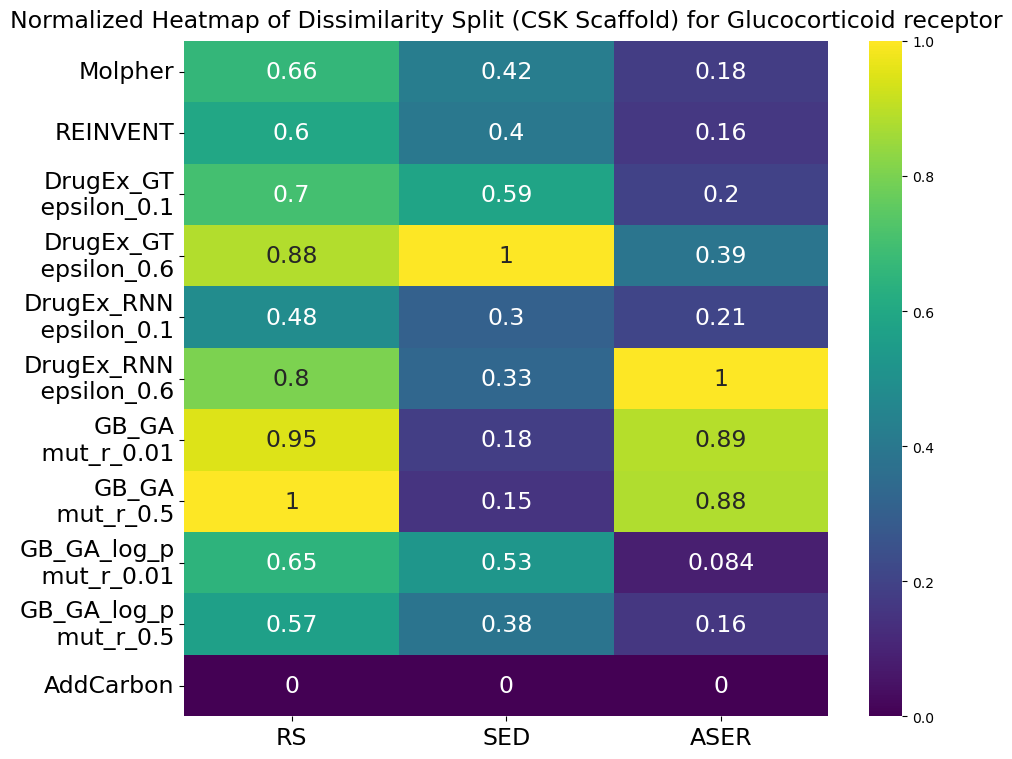

In [15]:
type_cluster = 'dis'
type_scaffold = 'csk'
subset = ''
generators_name_list = [
    f"Molpher{subset}",
    f"REINVENT{subset}",
    f"DrugEx_GT_epsilon_0.1{subset}",
    f"DrugEx_GT_epsilon_0.6{subset}",
    f"DrugEx_RNN_epsilon_0.1{subset}",
    f"DrugEx_RNN_epsilon_0.6{subset}",
    f"GB_GA_mut_r_0.01{subset}",
    f"GB_GA_mut_r_0.5{subset}",
    f"GB_GA_log_p_mut_r_0.01{subset}",
    f"GB_GA_log_p_mut_r_0.5{subset}",
    f"addcarbon{subset}"
]
receptor = 'Glucocorticoid_receptor'
            
if subset == '':
    subset = 'base'

#For poster we need a little different colors
poster = False

if poster == True:
    colors = ["#f4b285", "#aad1fd", "#b7d59e"] 
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    name_save = f'heatmap_{type_cluster}_{type_scaffold}{subset}_poster'
else:
    cmap = 'viridis'
    name_save = f'heatmap_{type_cluster}_{type_scaffold}{subset}'


if type_scaffold == 'csk':
    type_scaffold_str =  'CSK'
elif type_scaffold == 'murcko':
    type_scaffold_str = 'Murcko'
else:
    type_scaffold_str = type_scaff
if receptor == 'Glucocorticoid_receptor':
    receptor_str = 'Glucocorticoid receptor'
elif receptor == 'Leukocyte_elastase':
    receptor_str = 'Leukocyte elastase'
else:
    receptor_str = receptor
    
if type_cluster == 'dis':
    type_cluster_str = 'Dissimilarity'
elif type_cluster == 'sim':
    type_cluster_str = 'Similarity'
    
title = f'Normalized Heatmap of {type_cluster_str} Split ({type_scaffold_str} Scaffold) for {receptor_str}'
#title = f"Heatmap for {type_cluster} split and {type_scaffold_str} scaffold for {receptor_str}"
hv.plot_heatmap(type_cluster, type_scaffold, generators_name_list, receptor, title=title, cmap = cmap, name_save=name_save, using_norm_values = True, data_folder = data_folder, save_folder = f'../data/img/{receptor}')

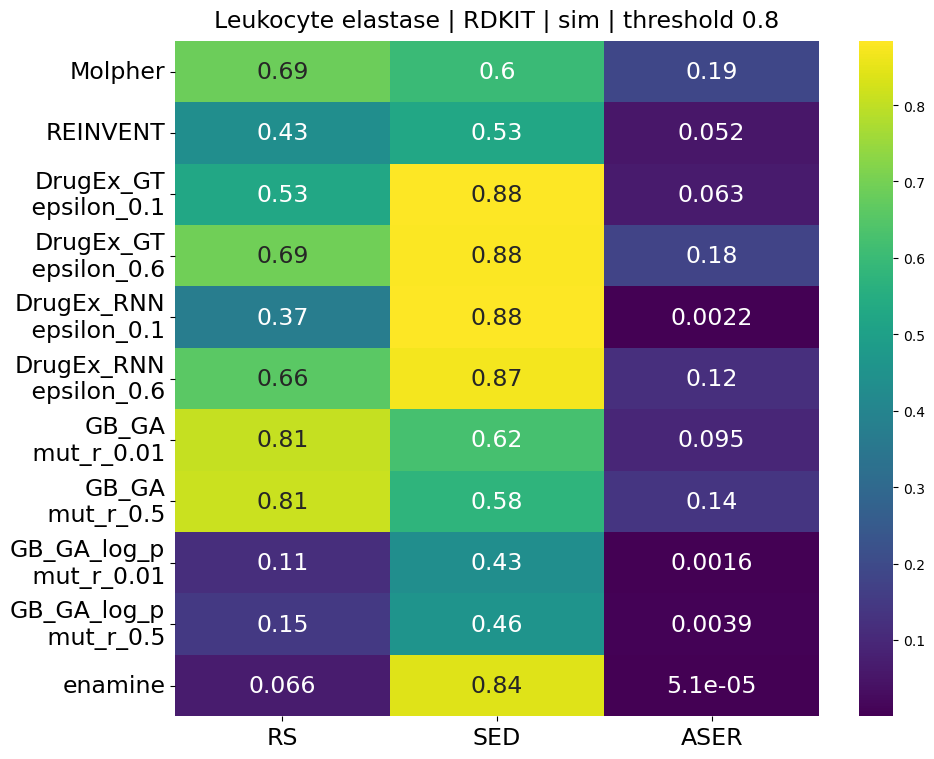

In [18]:
#Pharmacophore-based results

hv.plot_heatmap(
    type_cluster='sim',
    type_unit='rdkit',
    generators_name_list=[
        f"Molpher",
        f"REINVENT",
        f"DrugEx_GT_epsilon_0.1",
        f"DrugEx_GT_epsilon_0.6",
        f"DrugEx_RNN_epsilon_0.1",
        f"DrugEx_RNN_epsilon_0.6",
        f"GB_GA_mut_r_0.01",
        f"GB_GA_mut_r_0.5",
        f"GB_GA_log_p_mut_r_0.01",
        f"GB_GA_log_p_mut_r_0.5",
        f"enamine"
    ],
    receptor='Leukocyte_elastase',
    using_norm_values=False,
    data_folder=data_folder,
    ph4=True,
    user_threshold=0.8,
)

### Heatmap of different subsets visualized in a single plot.

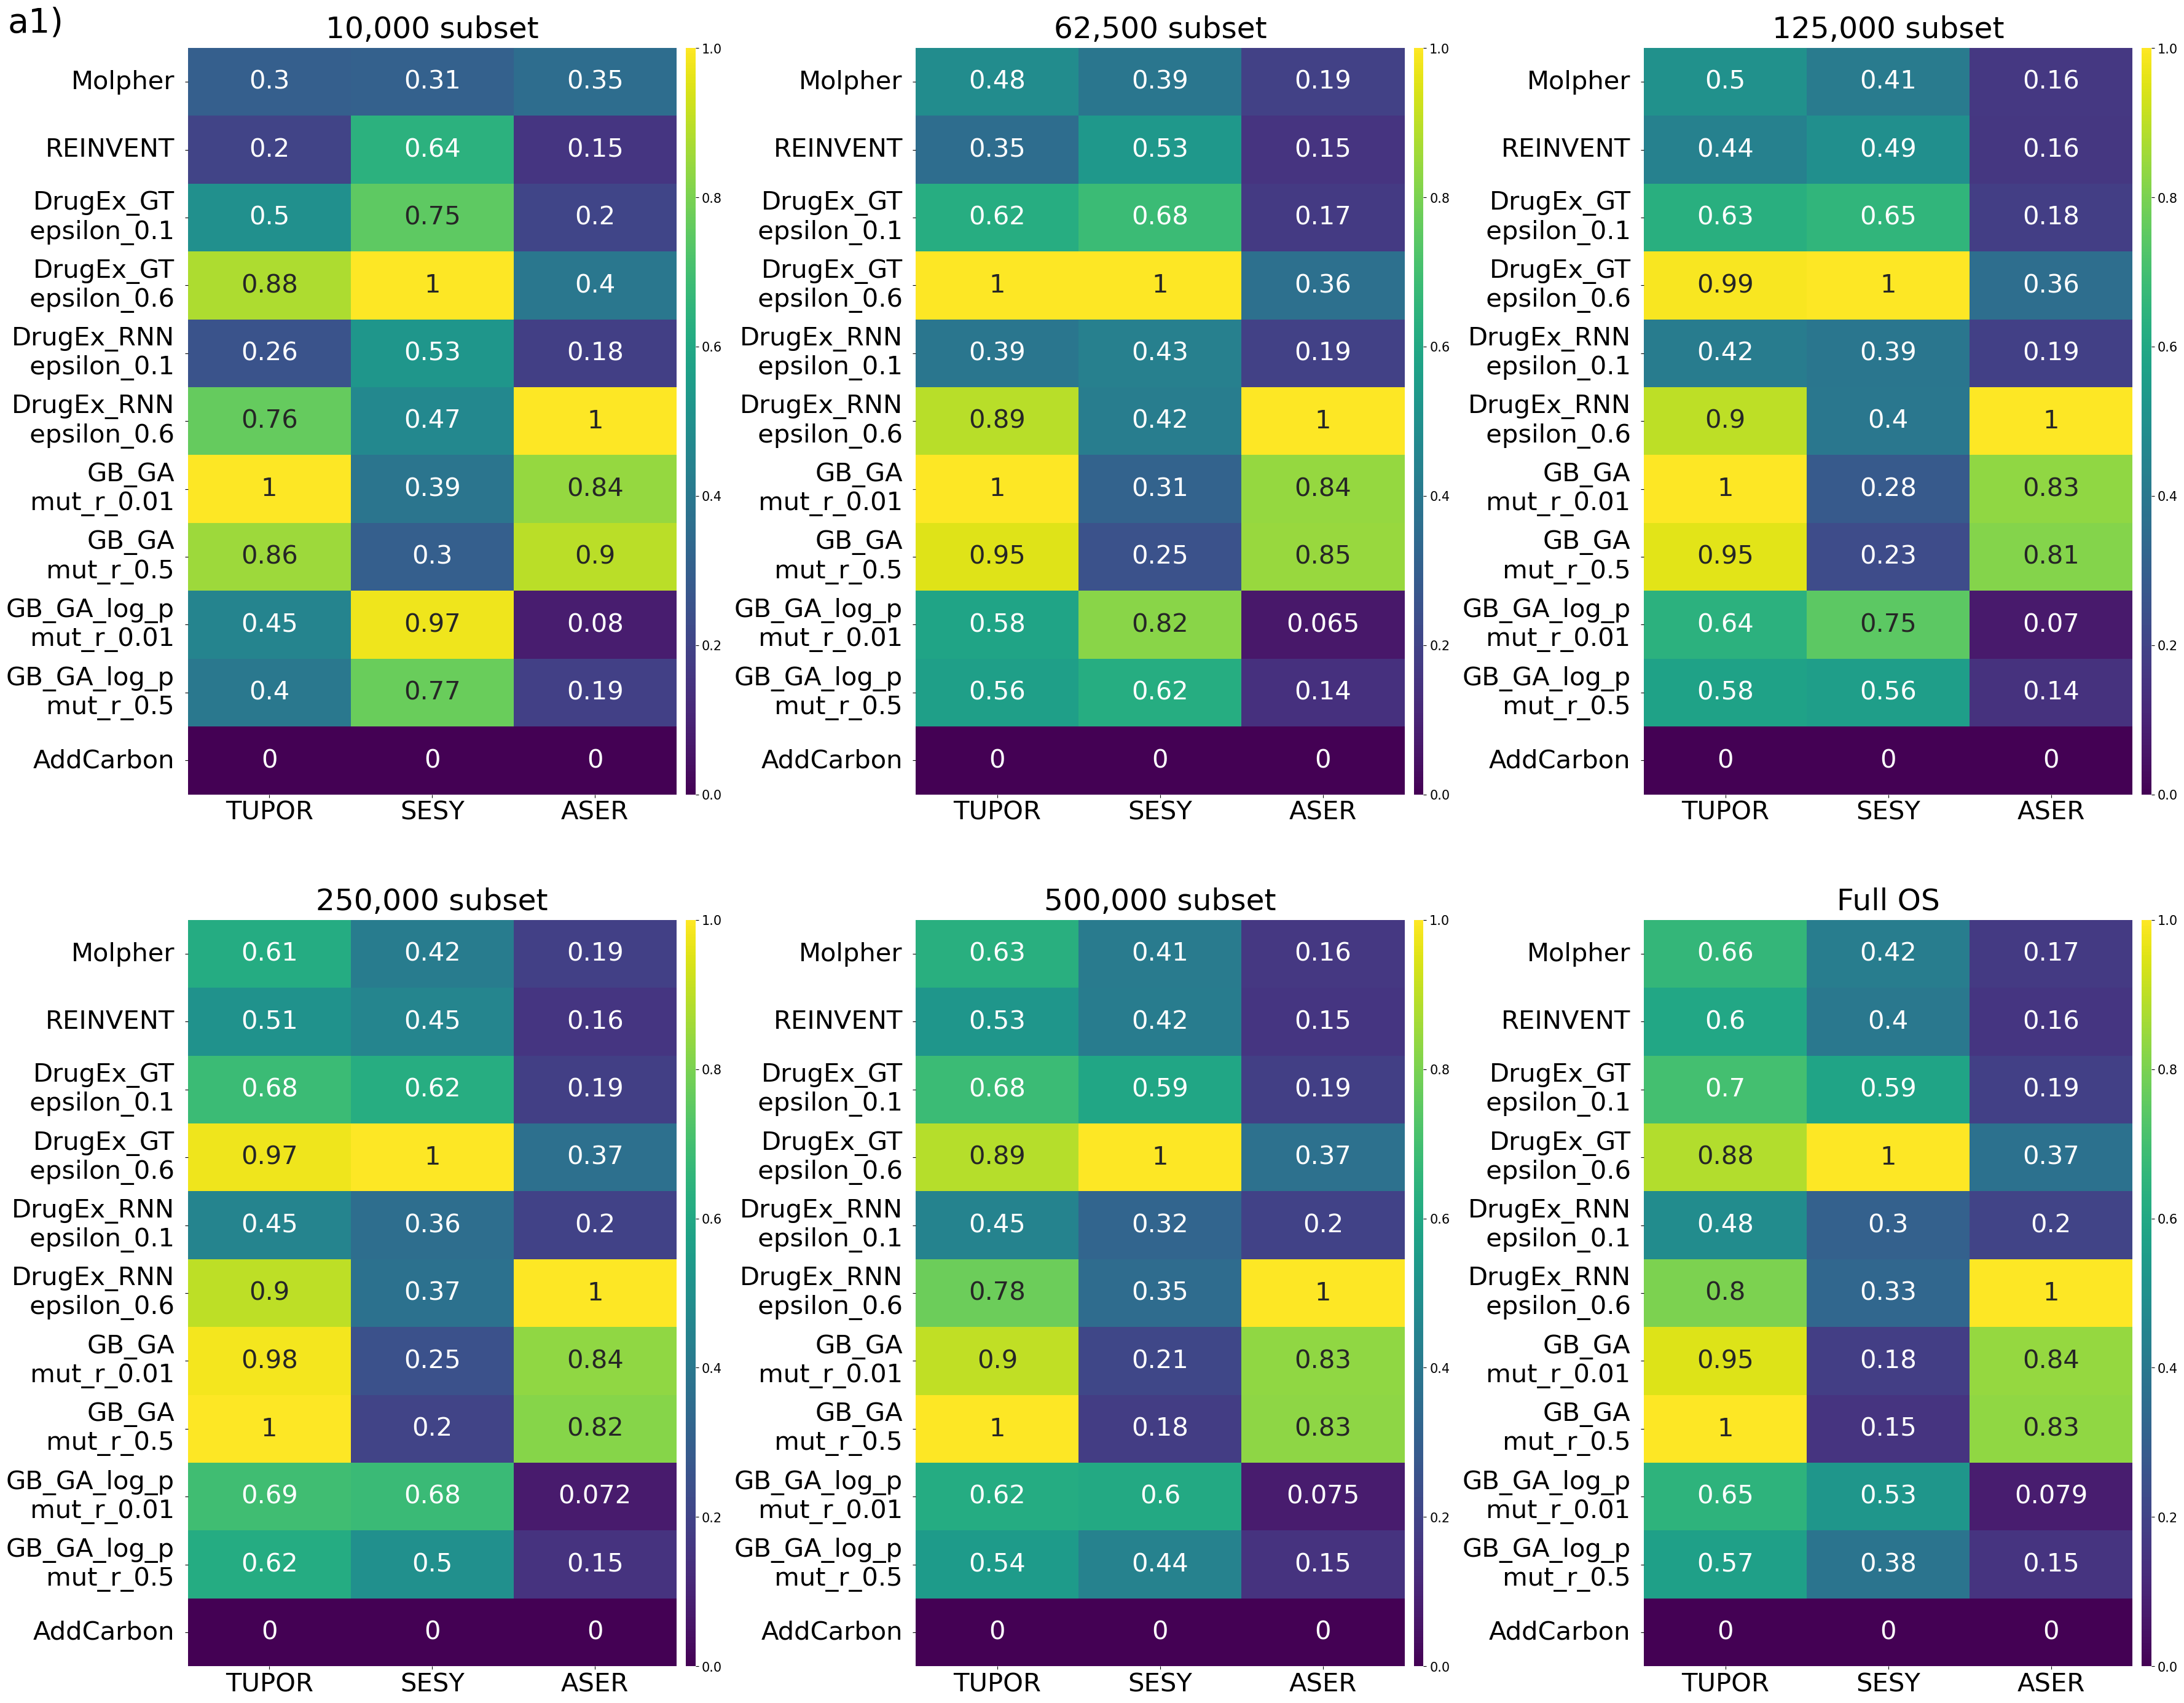

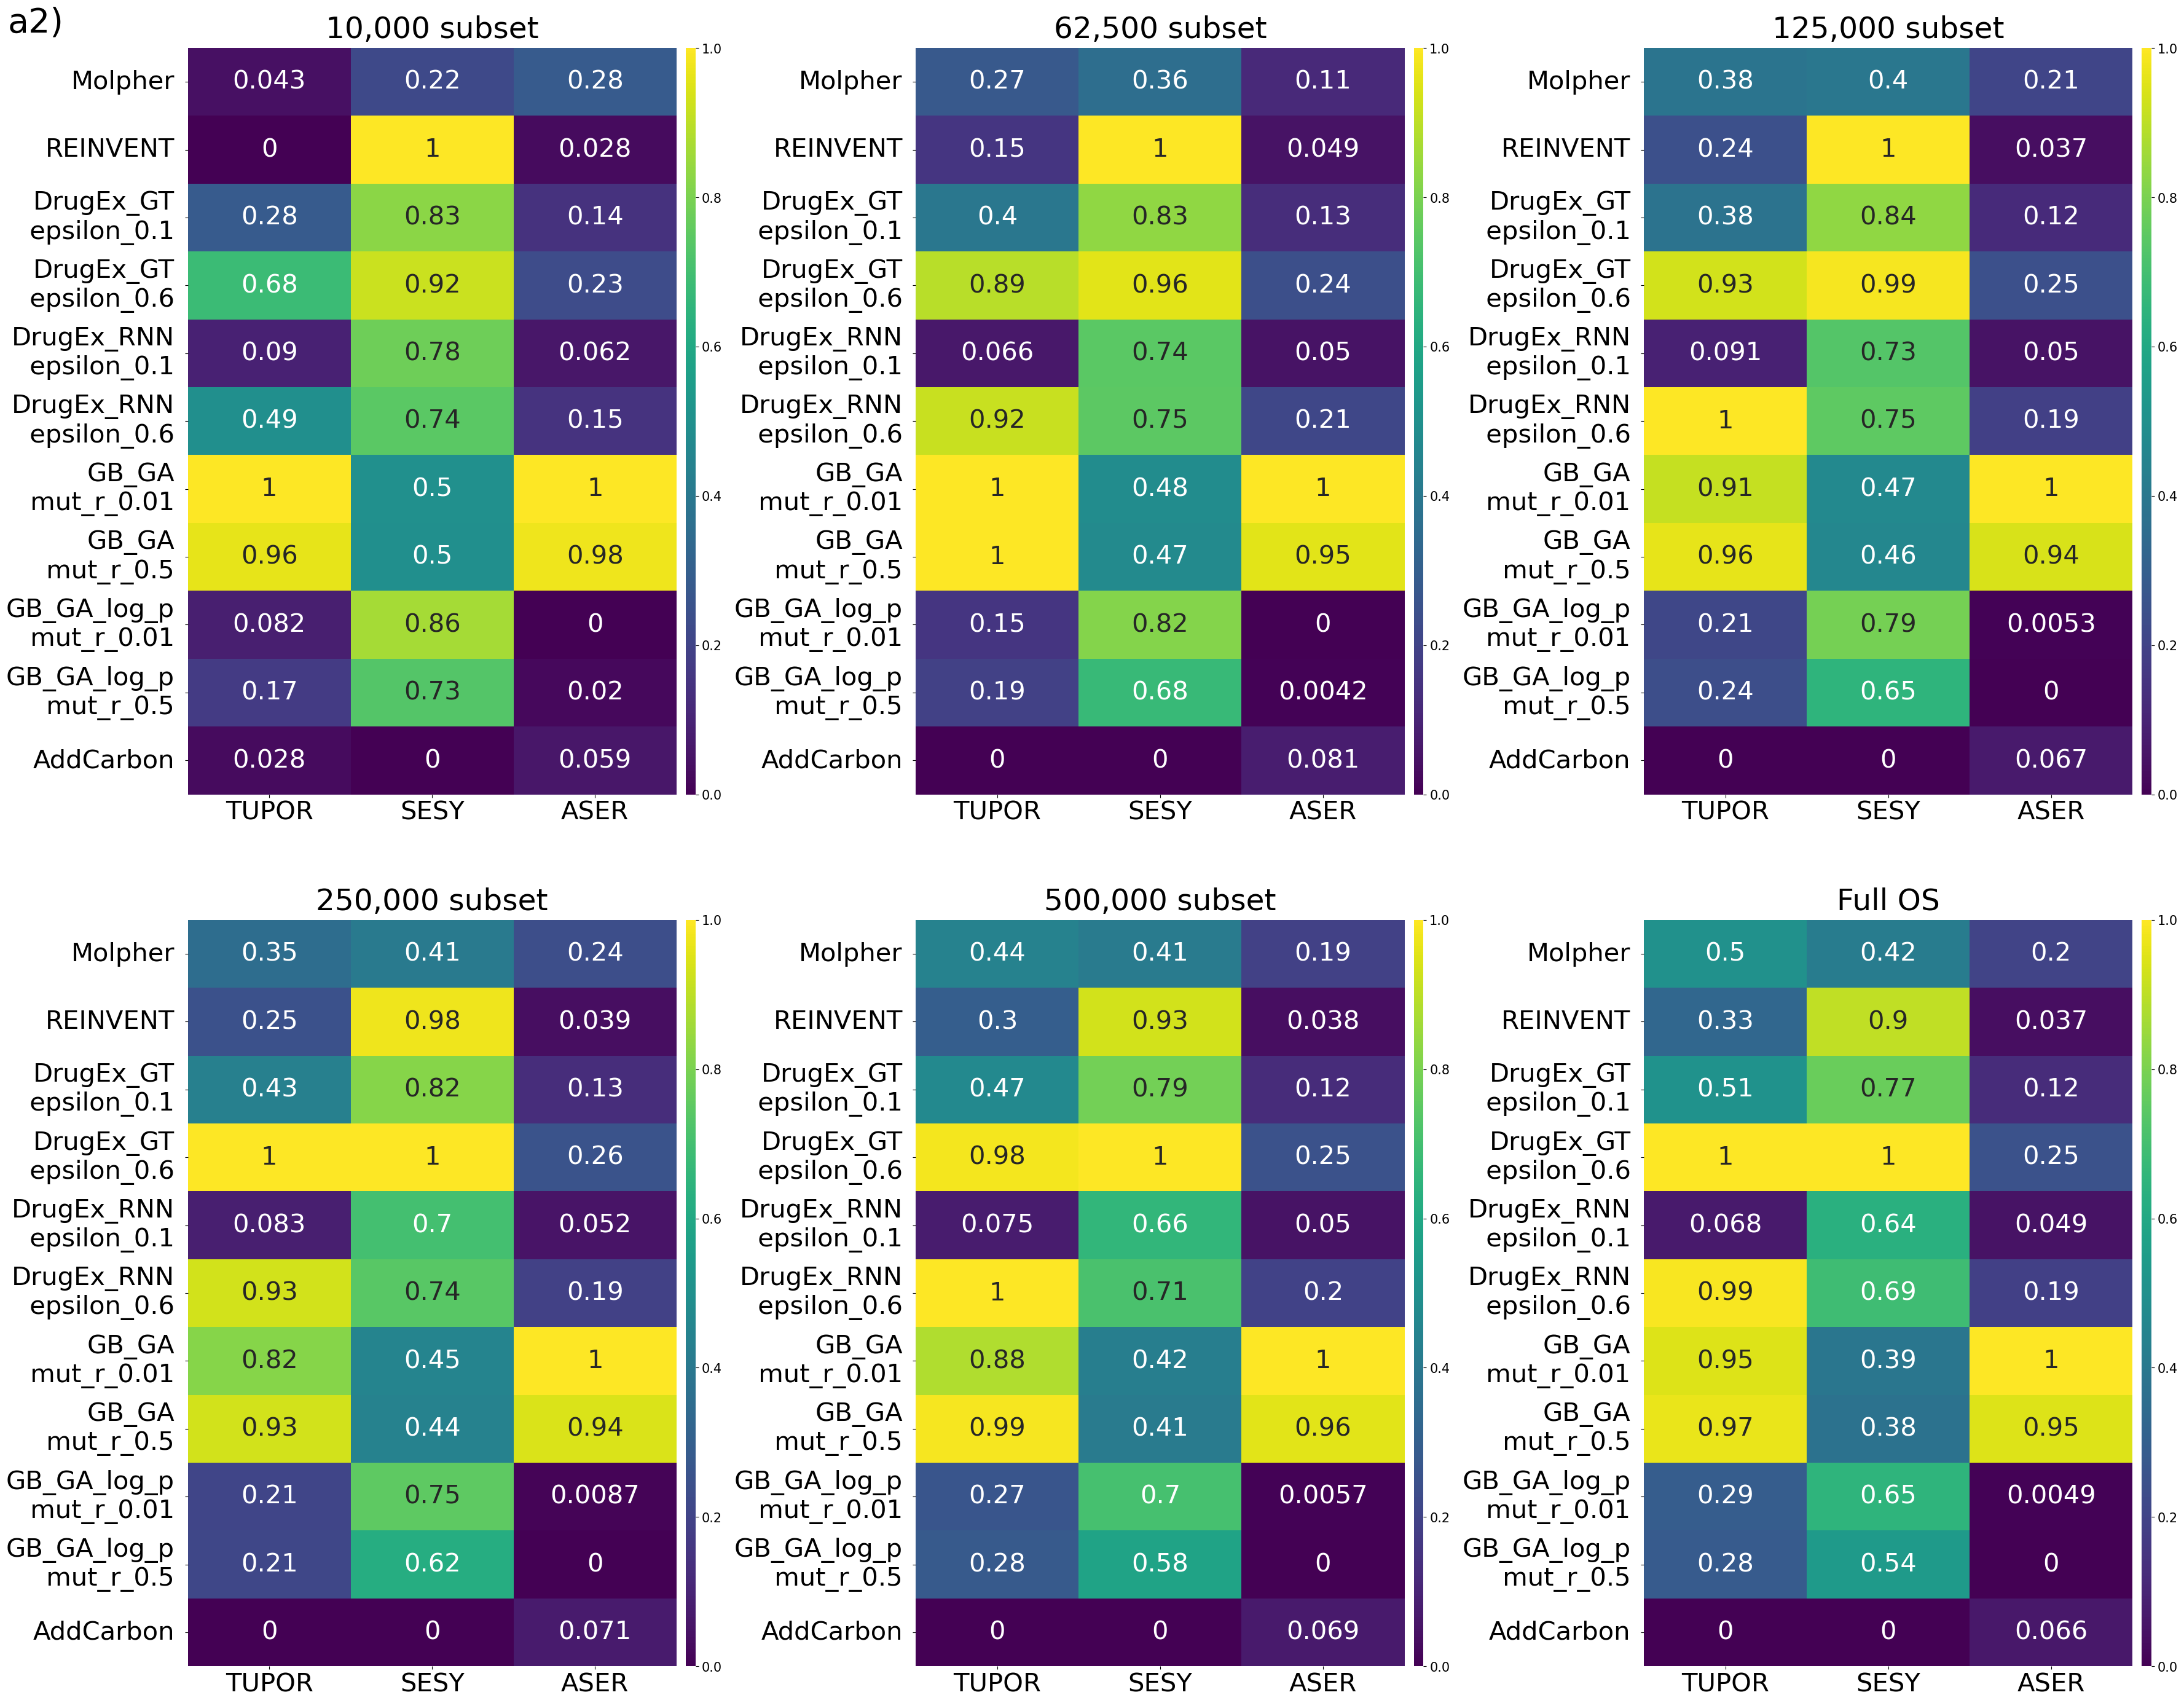

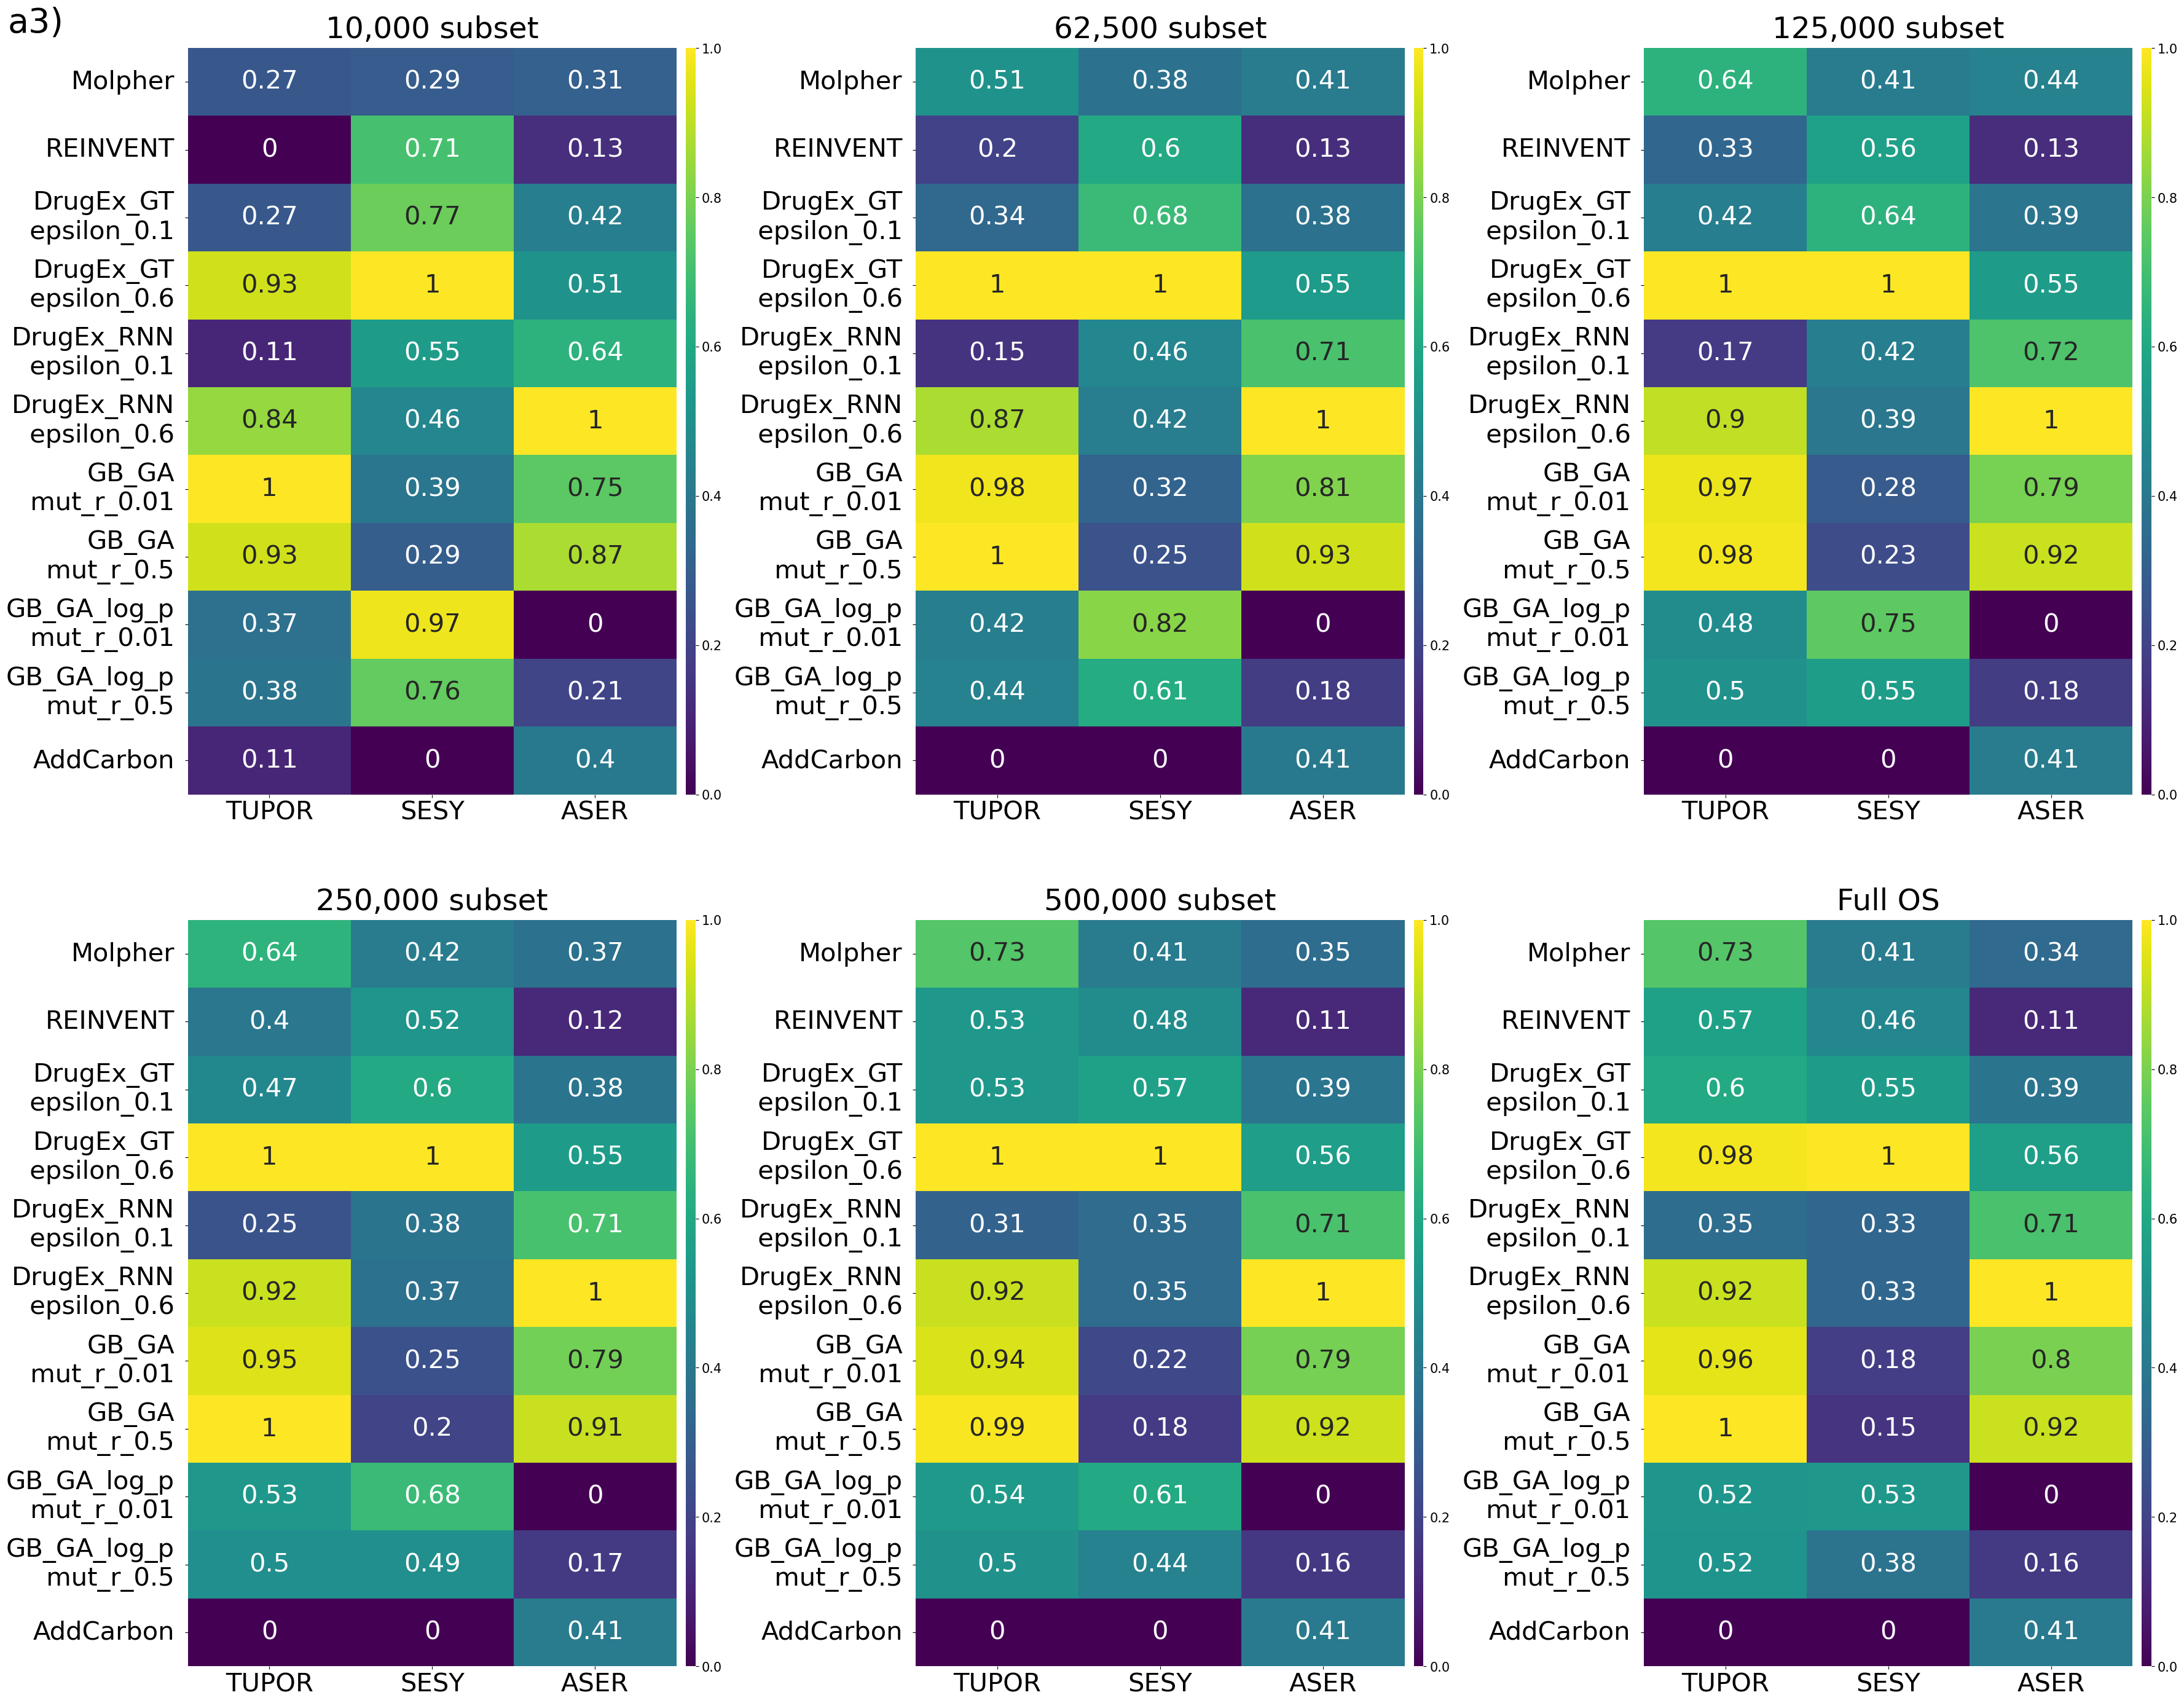

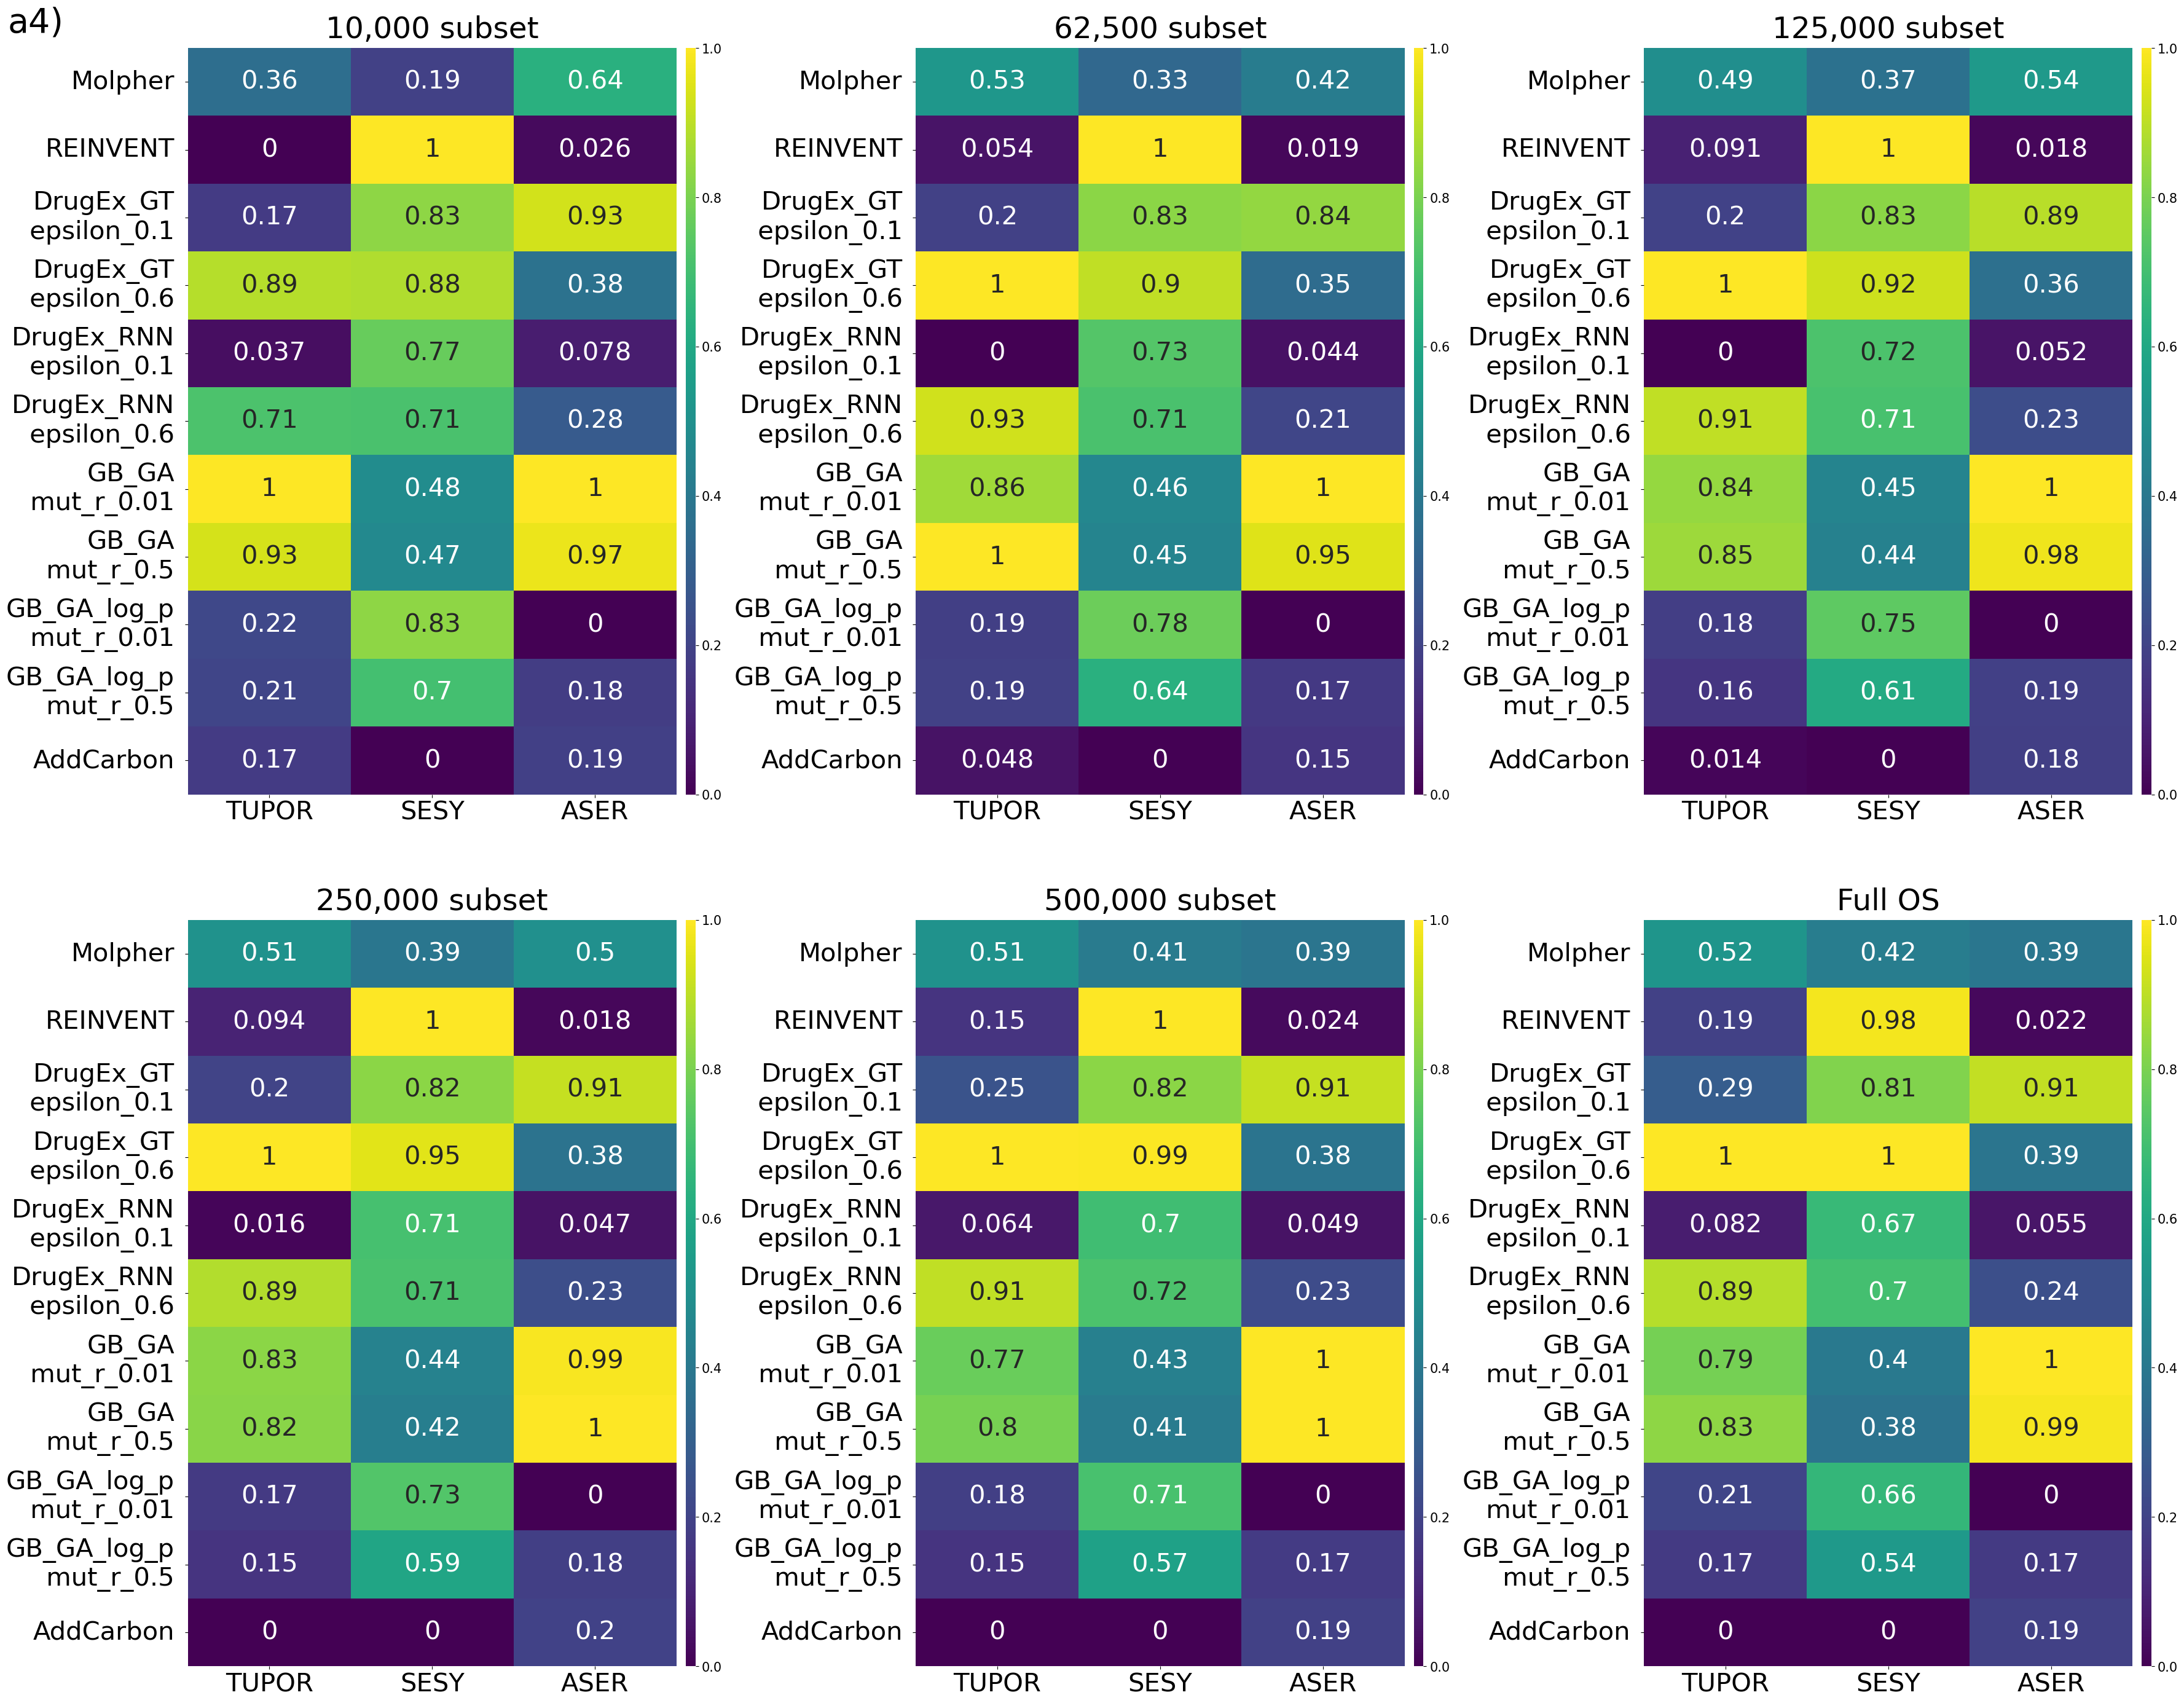

In [8]:
# Iterate through different types of splits (e.g., 'dis' and 'sim') and scaffold types (e.g., 'csk' and 'murcko')
count = 1
for type_cluster in ['dis', 'sim']:
    for type_scaffold in ['csk', 'murcko']:
        # Initialize an empty dictionary to store the data for each subset
        subset_dict = {}

        # Iterate through different subsets (base, 1k, 10k, 100k, 500k)
        for subset in ['_10k','_62.5k', '_125k', '_250k', '_500k', '']:
        #for subset in ['_10k', '']:
            receptor = 'Glucocorticoid_receptor'
            # Load the corresponding DataFrame from the CSV file based on the subset
            
            generators_name_list = [
                f"Molpher{subset}",
                f"REINVENT{subset}",
                f"DrugEx_GT_epsilon_0.1{subset}",
                f"DrugEx_GT_epsilon_0.6{subset}",
                f"DrugEx_RNN_epsilon_0.1{subset}",
                f"DrugEx_RNN_epsilon_0.6{subset}",
                f"GB_GA_mut_r_0.01{subset}",
                f"GB_GA_mut_r_0.5{subset}",
                f"GB_GA_log_p_mut_r_0.01{subset}",
                f"GB_GA_log_p_mut_r_0.5{subset}",
                f"addcarbon{subset}"
            ]

            using_norm_value = True #Define if use normalized values or not

            if using_norm_value:
                df = hv.preprocesing(type_cluster, type_scaffold, generators_name_list, receptor, data_folder)
            else:
                df = hv.preprocesing_org(type_cluster, type_scaffold, generators_name_list, receptor, data_folder)
            # Add the loaded data to the subset_dict with the subset name as the key
            subset_dict[subset] = df
        
        # Call the plot_all_subsets function to plot heatmaps for all subsets in the subset_dict
        name_save = f'6x1_heat_maps_{type_cluster}_{type_scaffold}_{receptor}'
        # The title for the heatmap figure is dynamically generated based on the scaffold type and split type

        if type_scaffold == 'csk':
            type_scaffold = 'CSK'

        num = f"a{count})"
        name_save = f'figure_13a{count}'
        #num = ""
        
        #title=f'Heatmaps for {type_scaffold} scaffolds and {type_cluster} split for {receptor.replace("_", " ")}'
        hv.plot_all_subsets(subset_dict, receptor = receptor, name_save=name_save, numering = num, save_folder = f'../img/paper/figure_13/figure_a{count}')
        count += 1

### Heatmaps for Compared to Baseline Data for Different Split Types and Scaffold Combinations


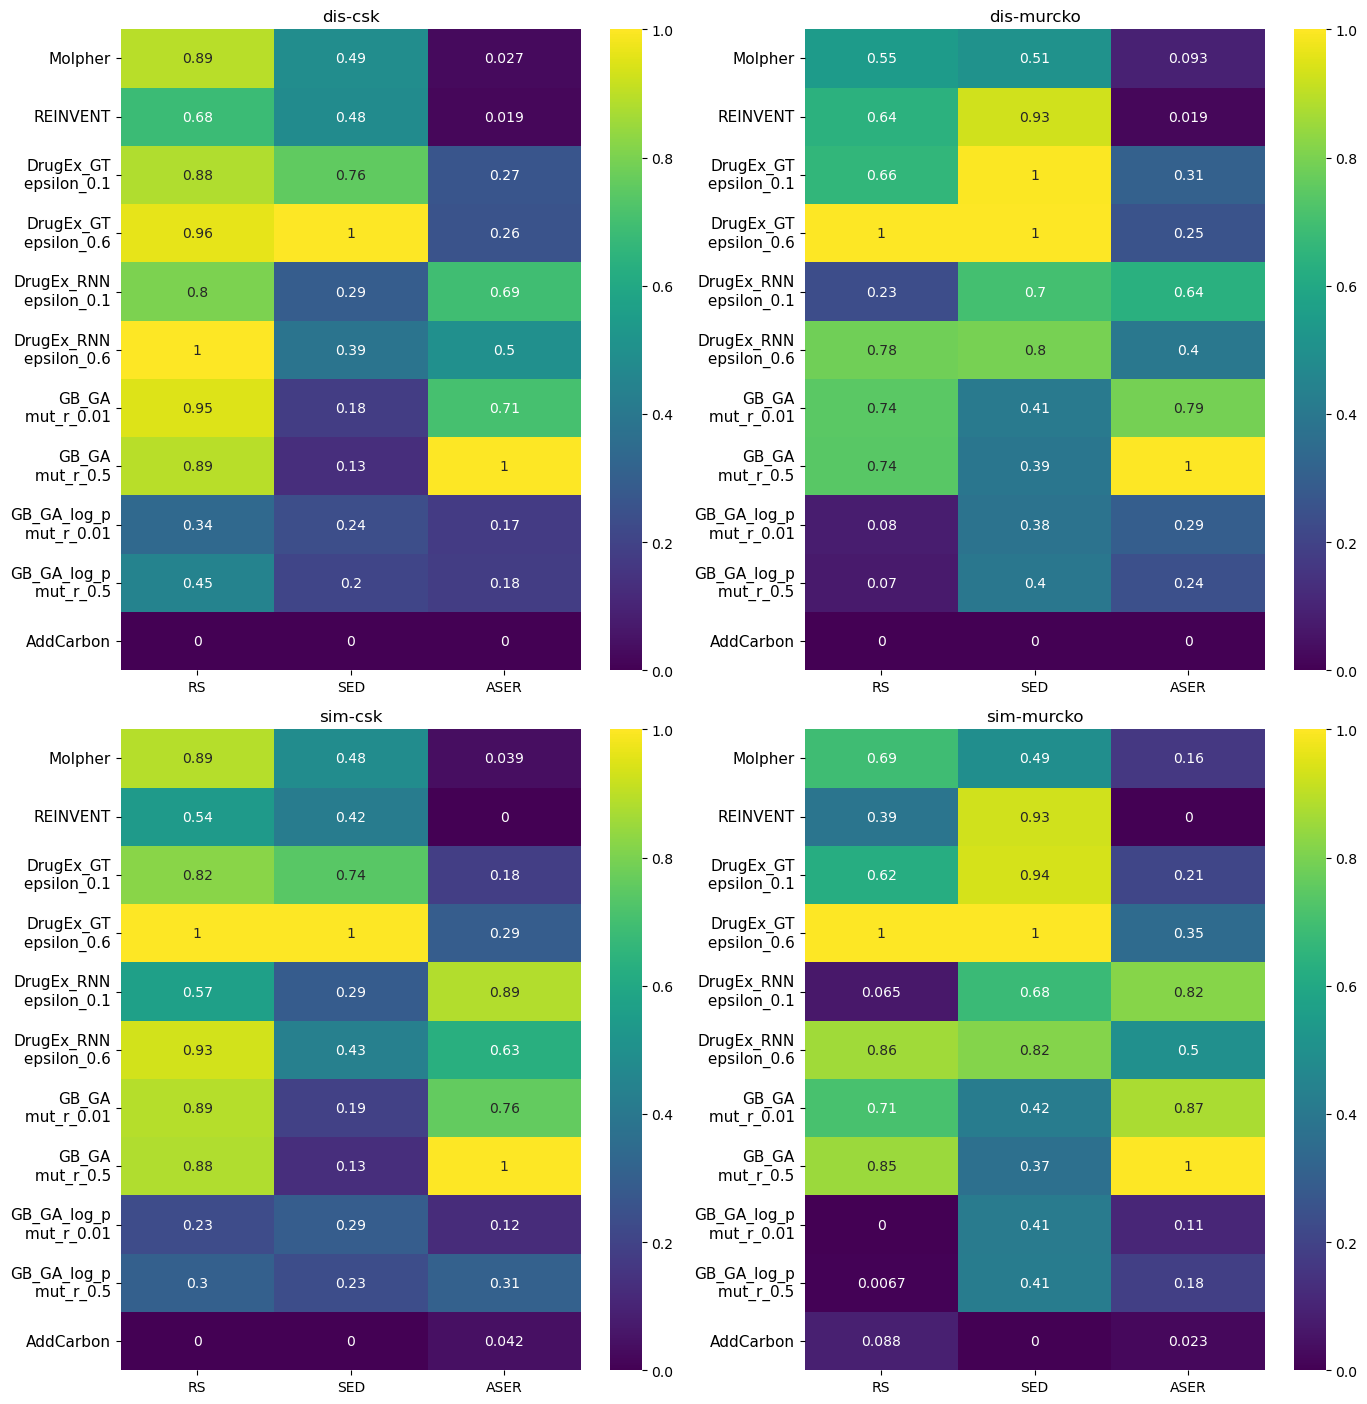

In [19]:
# Initialize empty dictionaries to store data and titles for each subset
subset_dict = {}
subset_dict_data = {}

# Iterate over the different types of splits ('dis', 'sim') and scaffold types ('csk', 'murcko')
for i, type_cluster in enumerate(['dis', 'sim']):
    for j, type_scaffold in enumerate(['csk', 'murcko']):
        receptor = 'Leukocyte_elastase'
        # Load the DataFrame for the 'base' subset from the corresponding CSV file
        # The file path is constructed dynamically based on the type_split and scaf
        generators_name_list = [
                f"Molpher",
                f"REINVENT",
                f"DrugEx_GT_epsilon_0.1",
                f"DrugEx_GT_epsilon_0.6",
                f"DrugEx_RNN_epsilon_0.1",
                f"DrugEx_RNN_epsilon_0.6",
                f"GB_GA_mut_r_0.01",
                f"GB_GA_mut_r_0.5",
                f"GB_GA_log_p_mut_r_0.01",
                f"GB_GA_log_p_mut_r_0.5",
                f"addcarbon"
            ]

        using_norm_value = True #Define if use normalized values or not

        if using_norm_value:
            df = hv.preprocesing(type_cluster, type_scaffold, generators_name_list, receptor, data_folder)
        else:
            df = hv.preprocesing_org(type_cluster, type_scaffold, generators_name_list, receptor, data_folder)
        
        # Store the loaded DataFrame in the subset_dict with a key representing its position in the grid (i,j)
        subset_dict[f'{i},{j}'] = df
        
        # Store a descriptive title for the subset in subset_dict_data (e.g., 'dis-csk', 'sim-murcko')
        subset_dict_data[f'{i},{j}'] = f'{type_cluster}-{type_scaffold}'
#colors = ["#f4b285", "#aad1fd", "#b7d59e"] 
#cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

name_save = 'heat_map_comparison_base_all_splits_paper'
# Call the plot_heatmap_base function to plot the heatmaps for all subsets in the subset_dict
# The title 'Heatmaps' will be displayed for the overall figure
#f'Heatmaps for various split types nad scaffold combination for base subset for {receptor}'
hv.plot_heatmap_base(subset_dict, subset_dict_data, title = '', receptor = receptor, name_save = name_save, save_folder = f'../img/{receptor}')


### Heatmaps for Differences Between Baseline and Other Subsets

/home/filv/miniconda3/envs/metrics-env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/filv/miniconda3/envs/metrics-env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


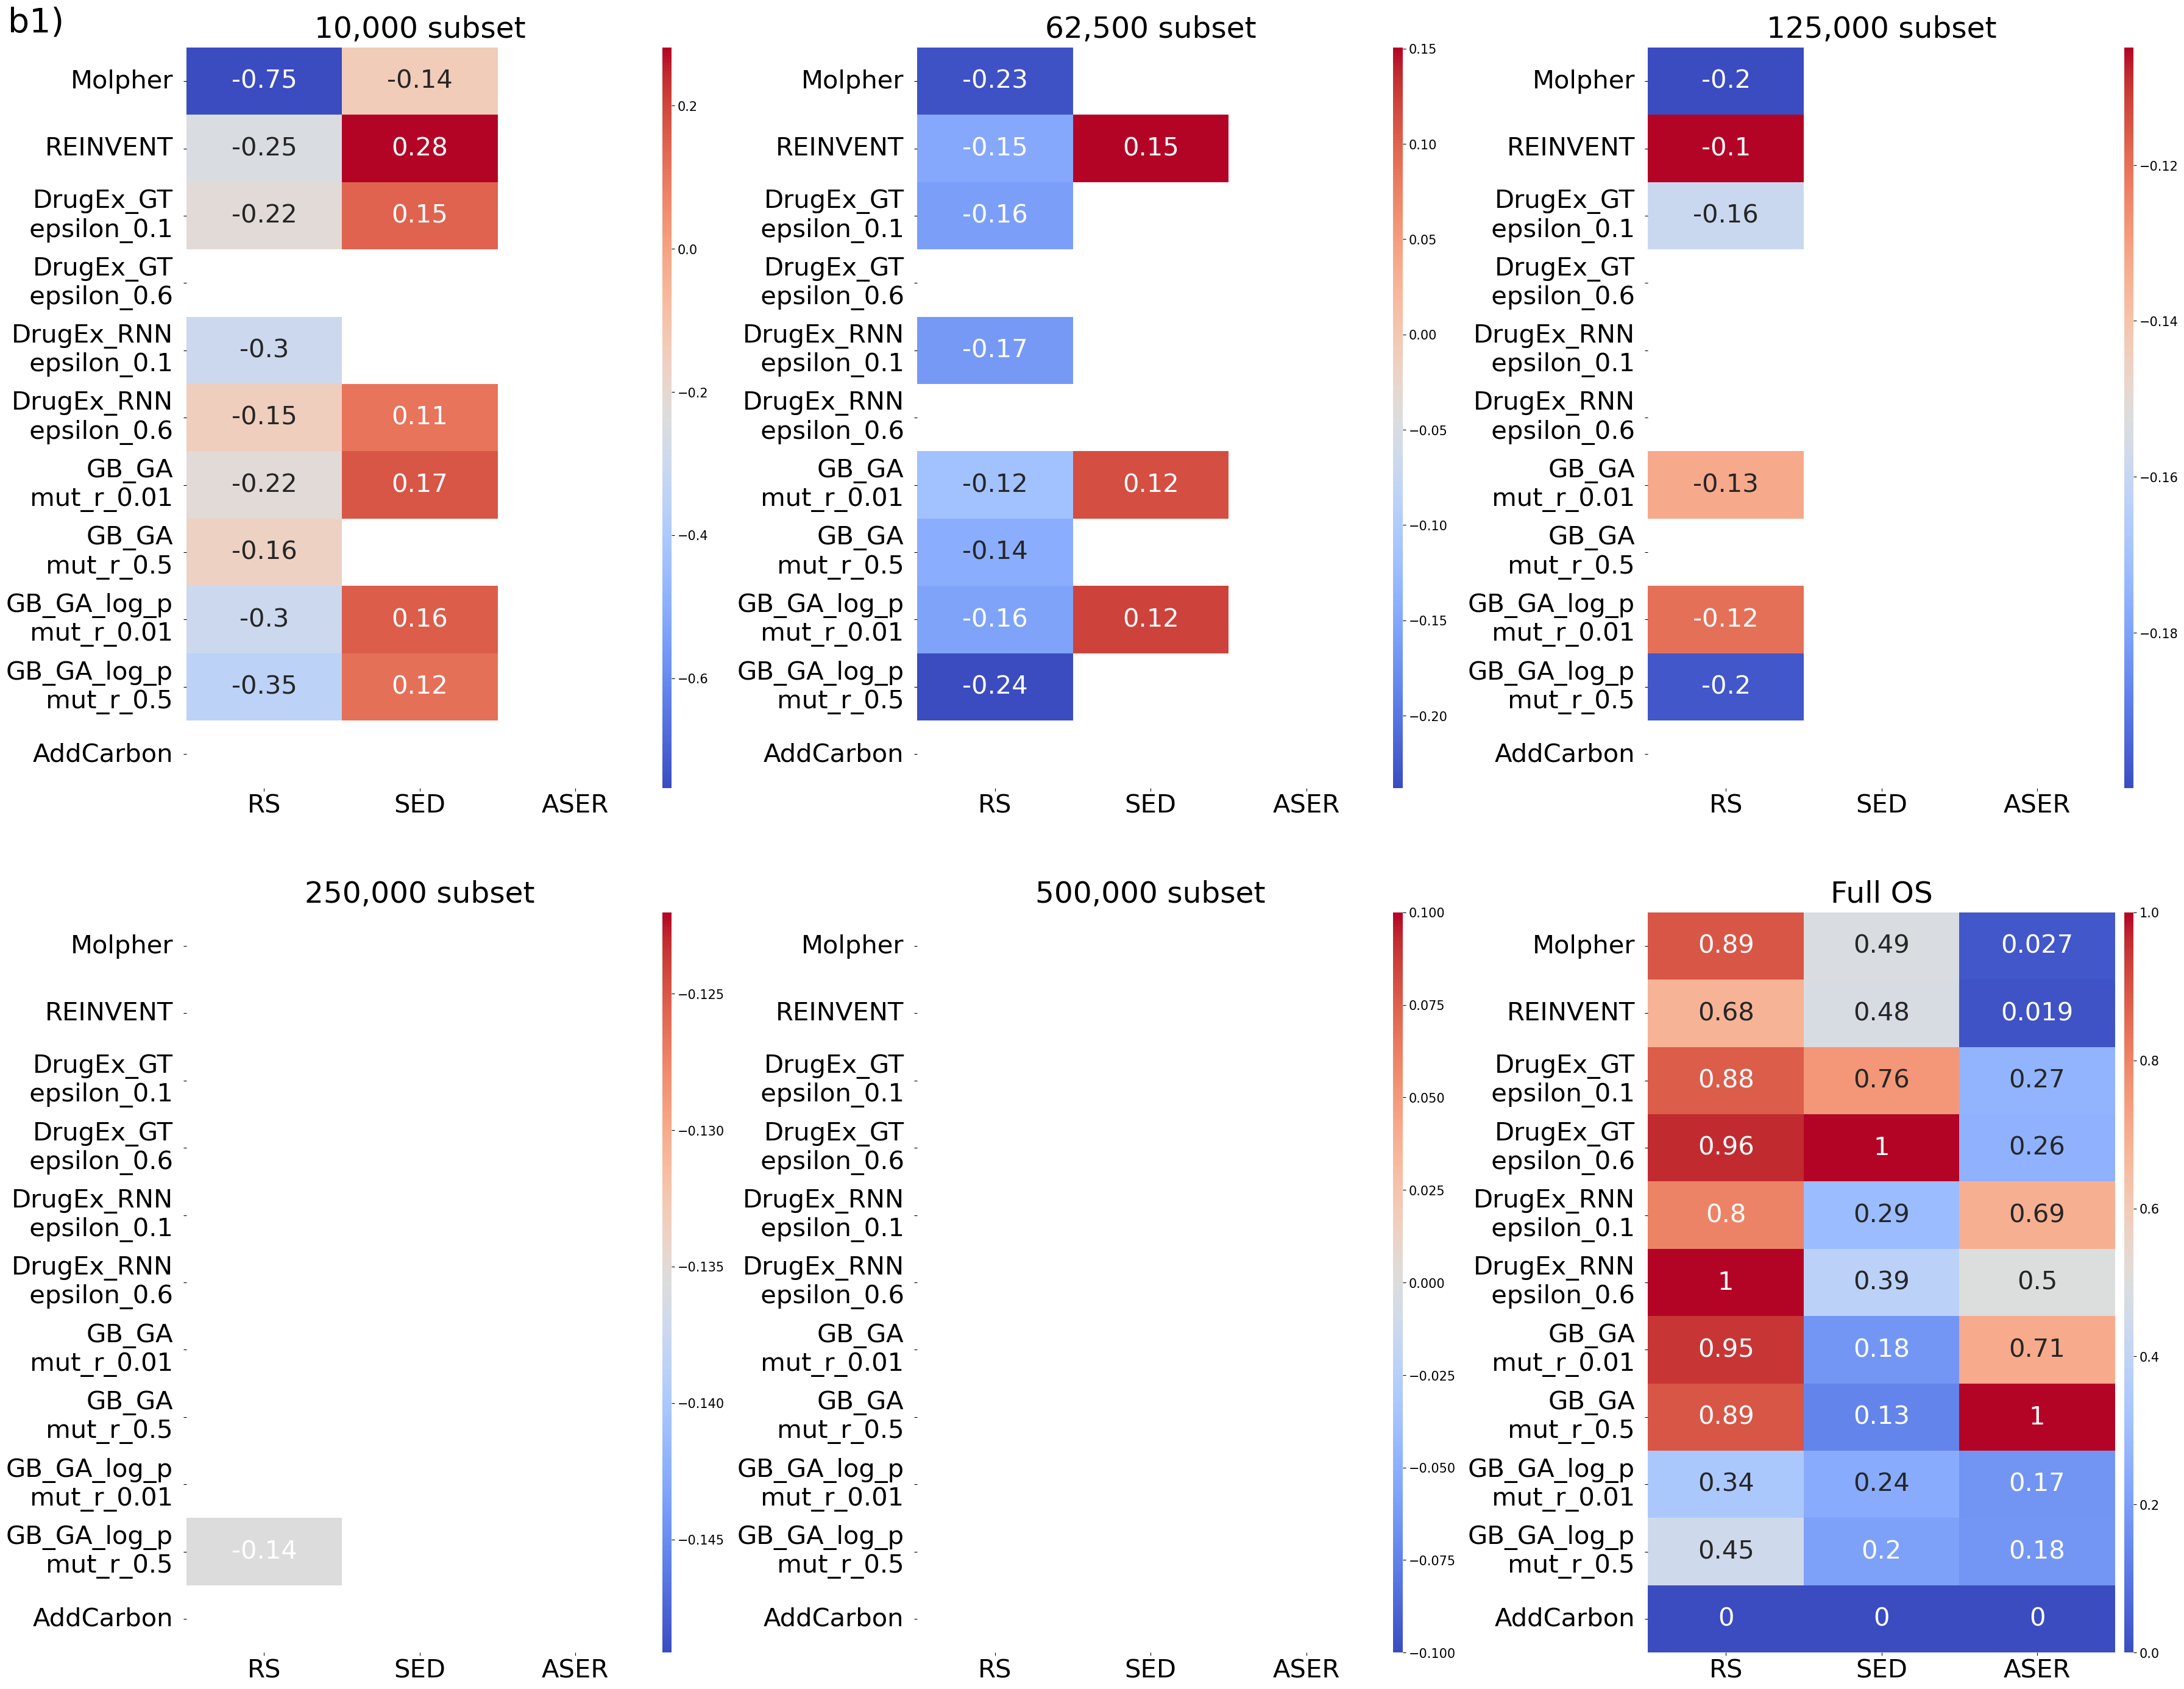

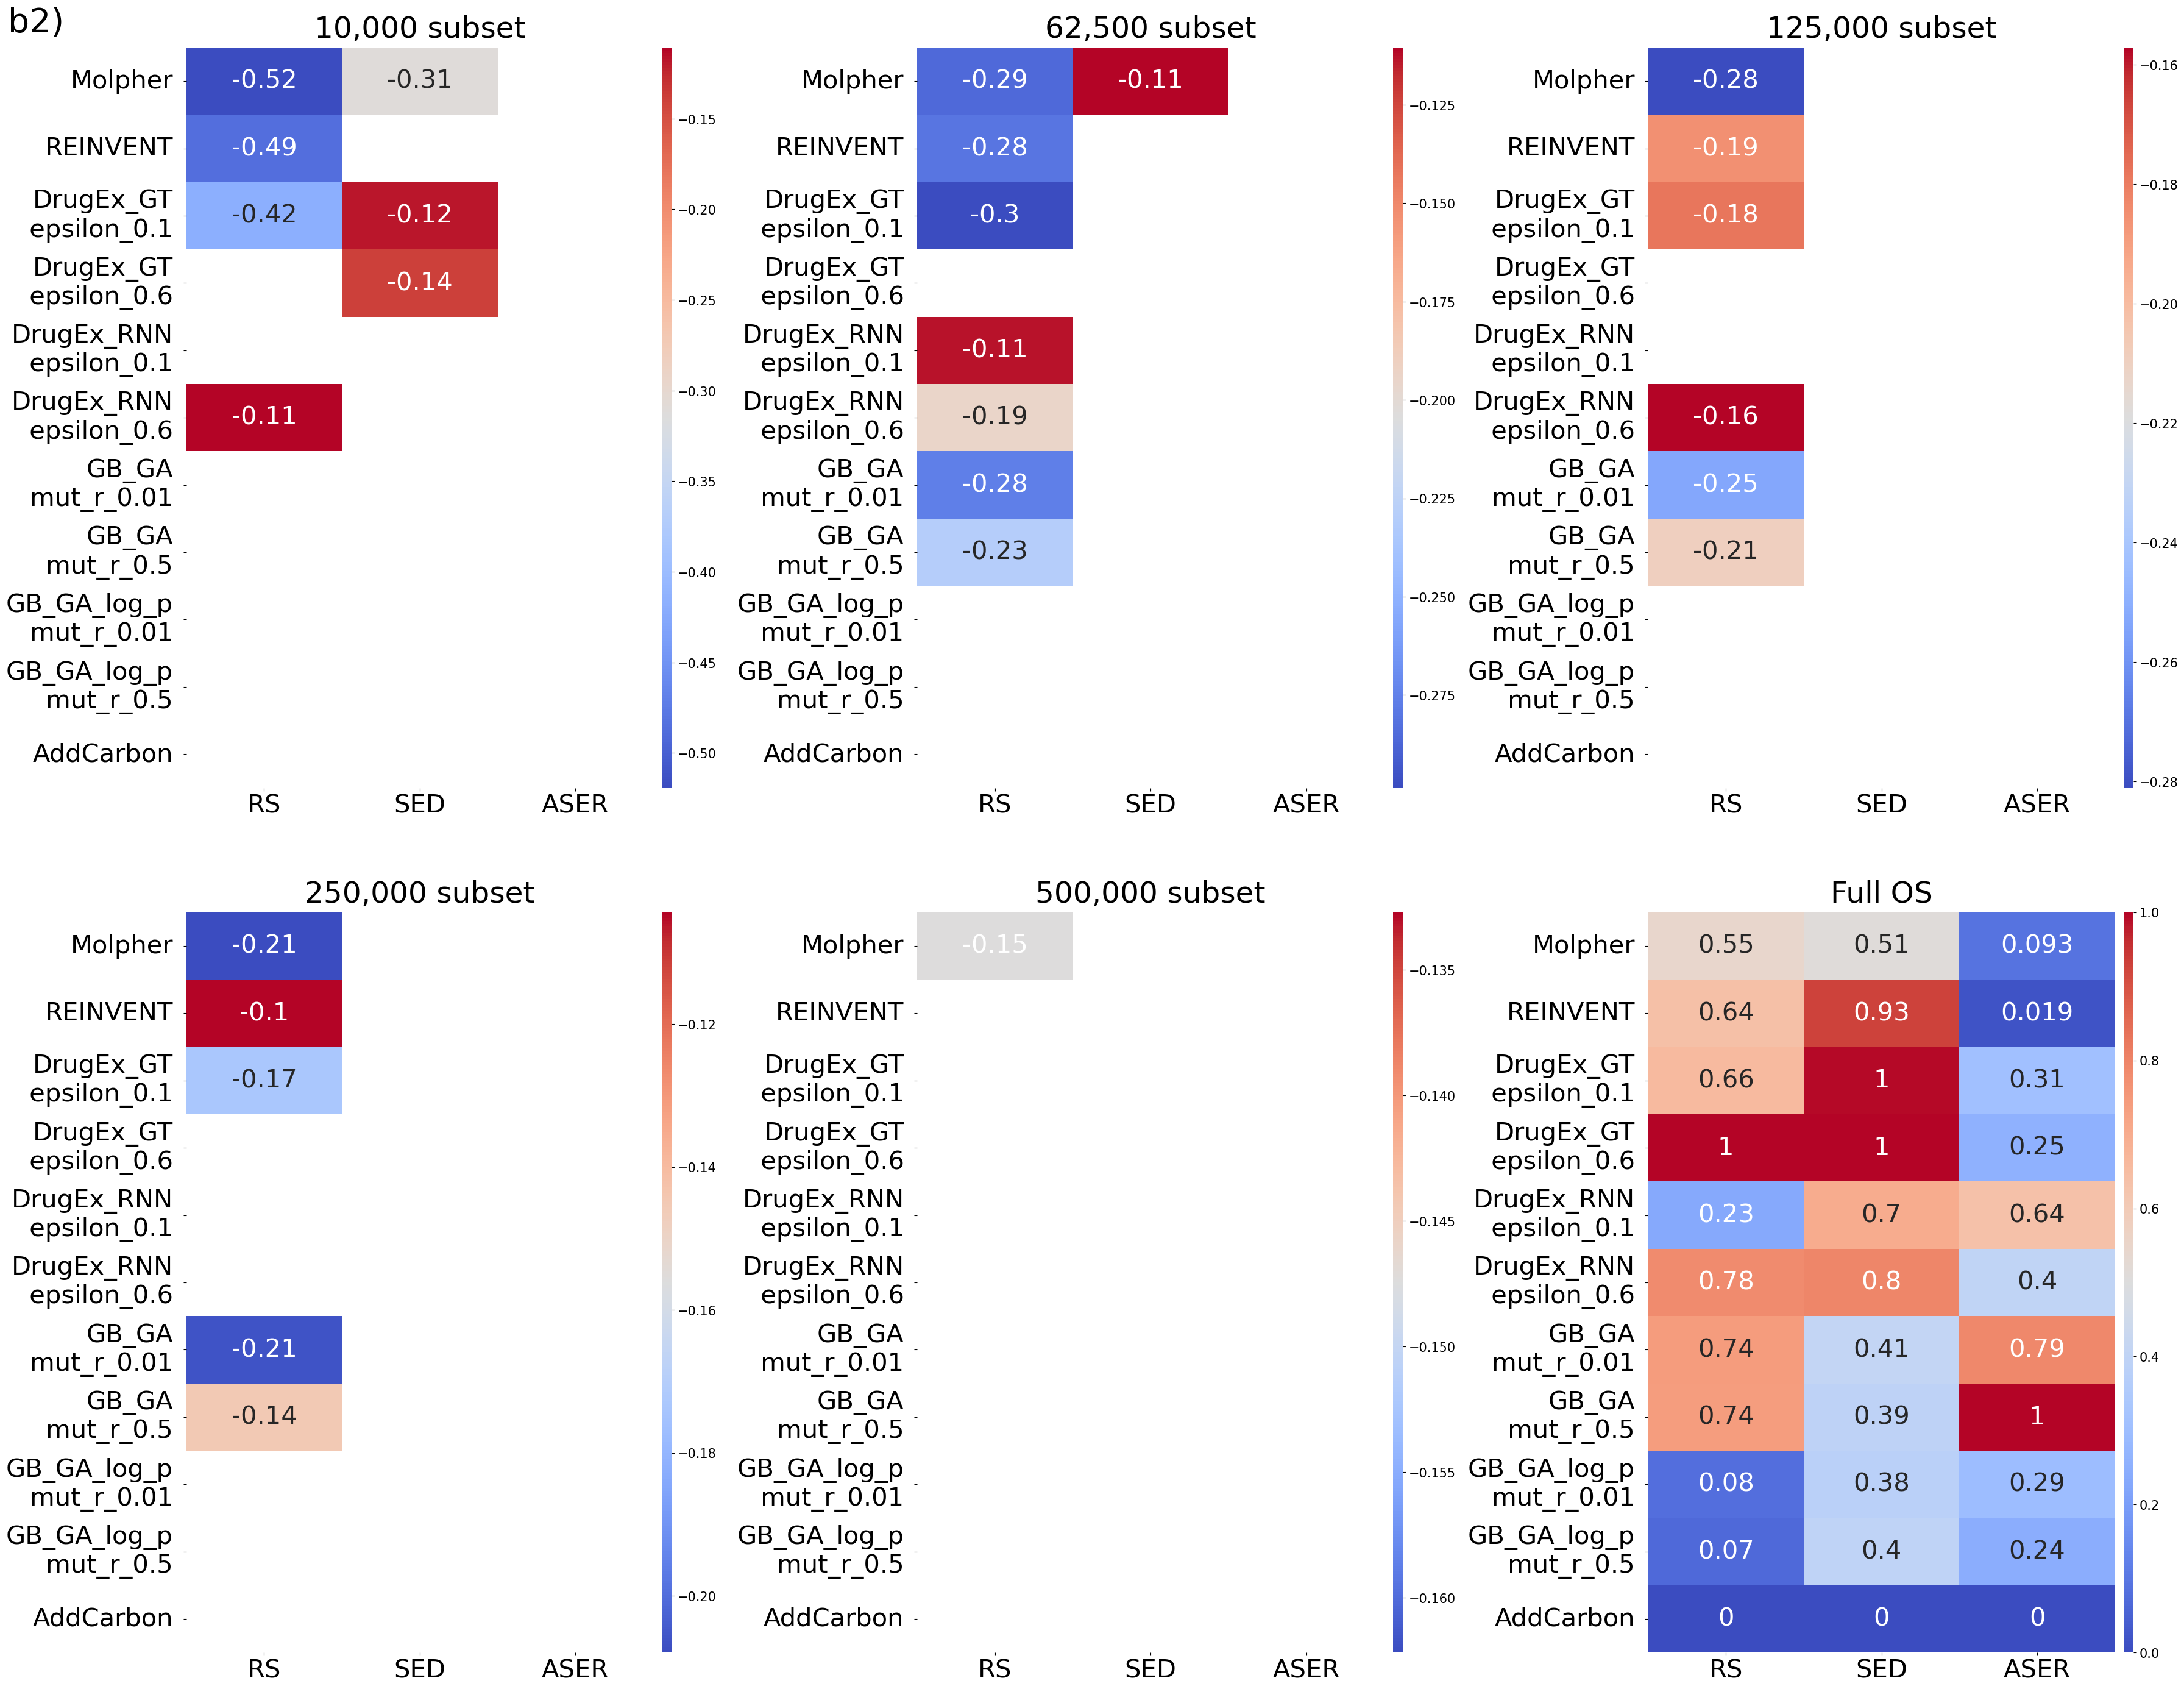

/home/filv/miniconda3/envs/metrics-env/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/filv/miniconda3/envs/metrics-env/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


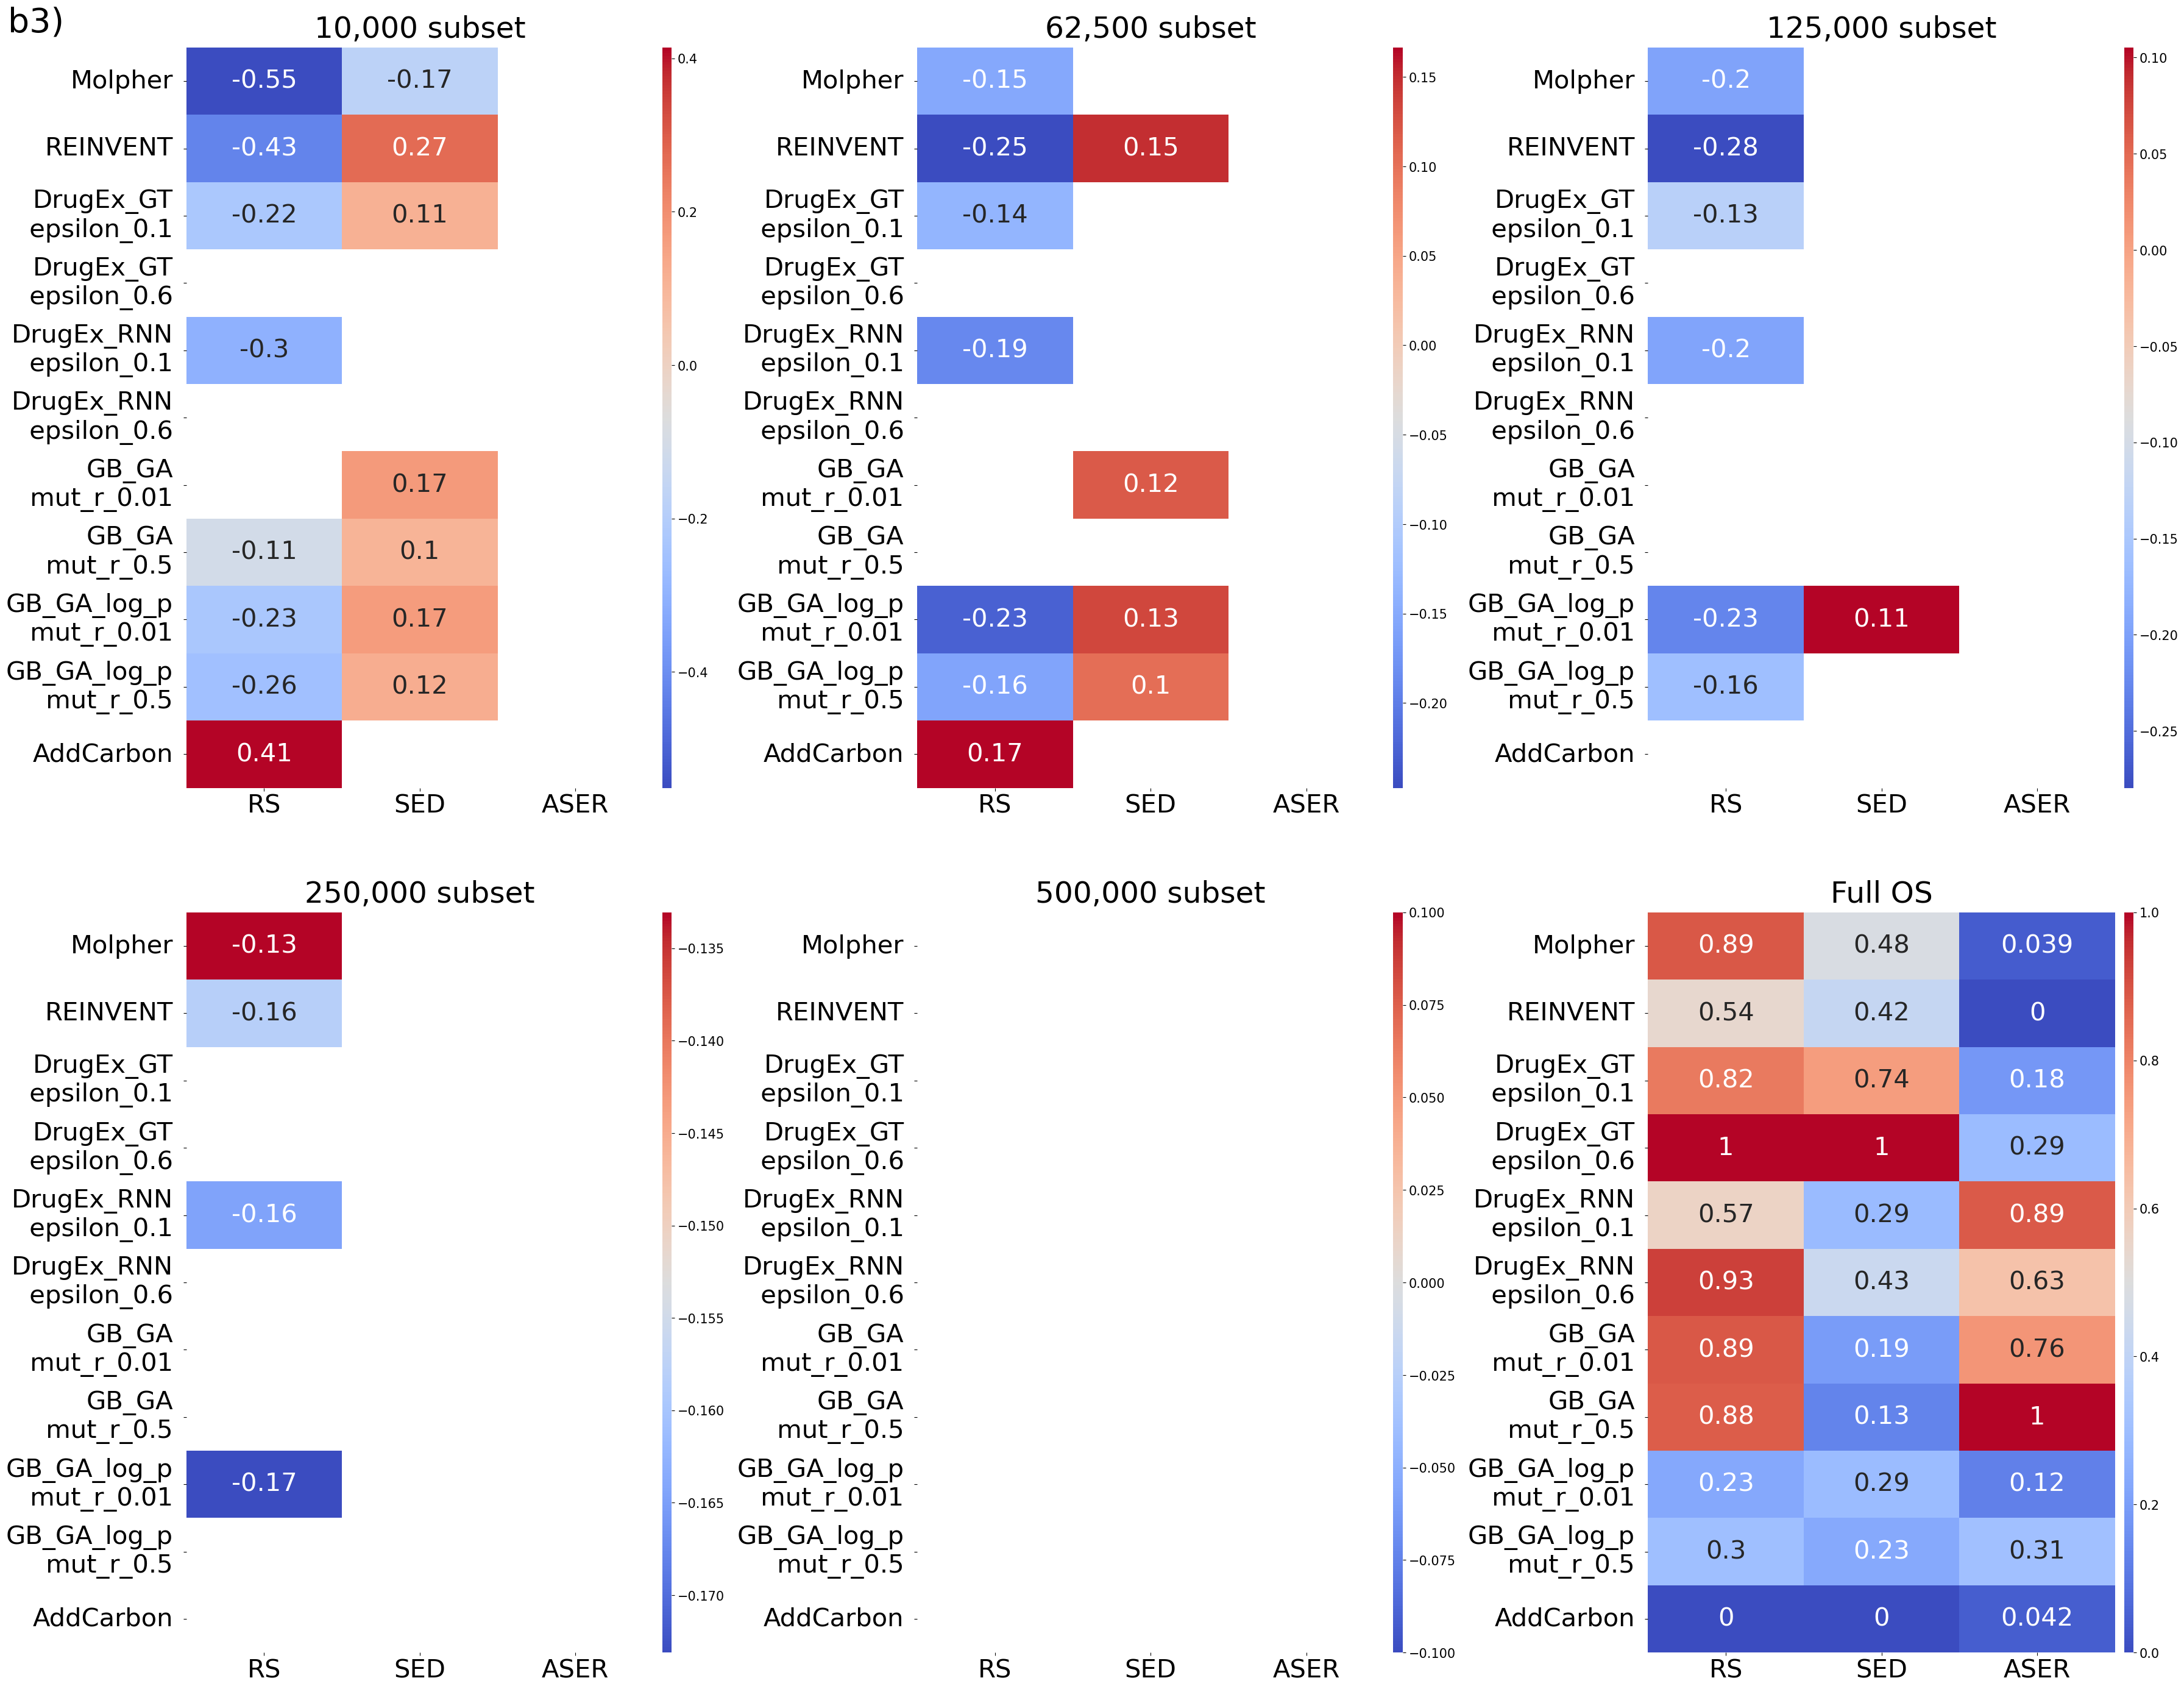

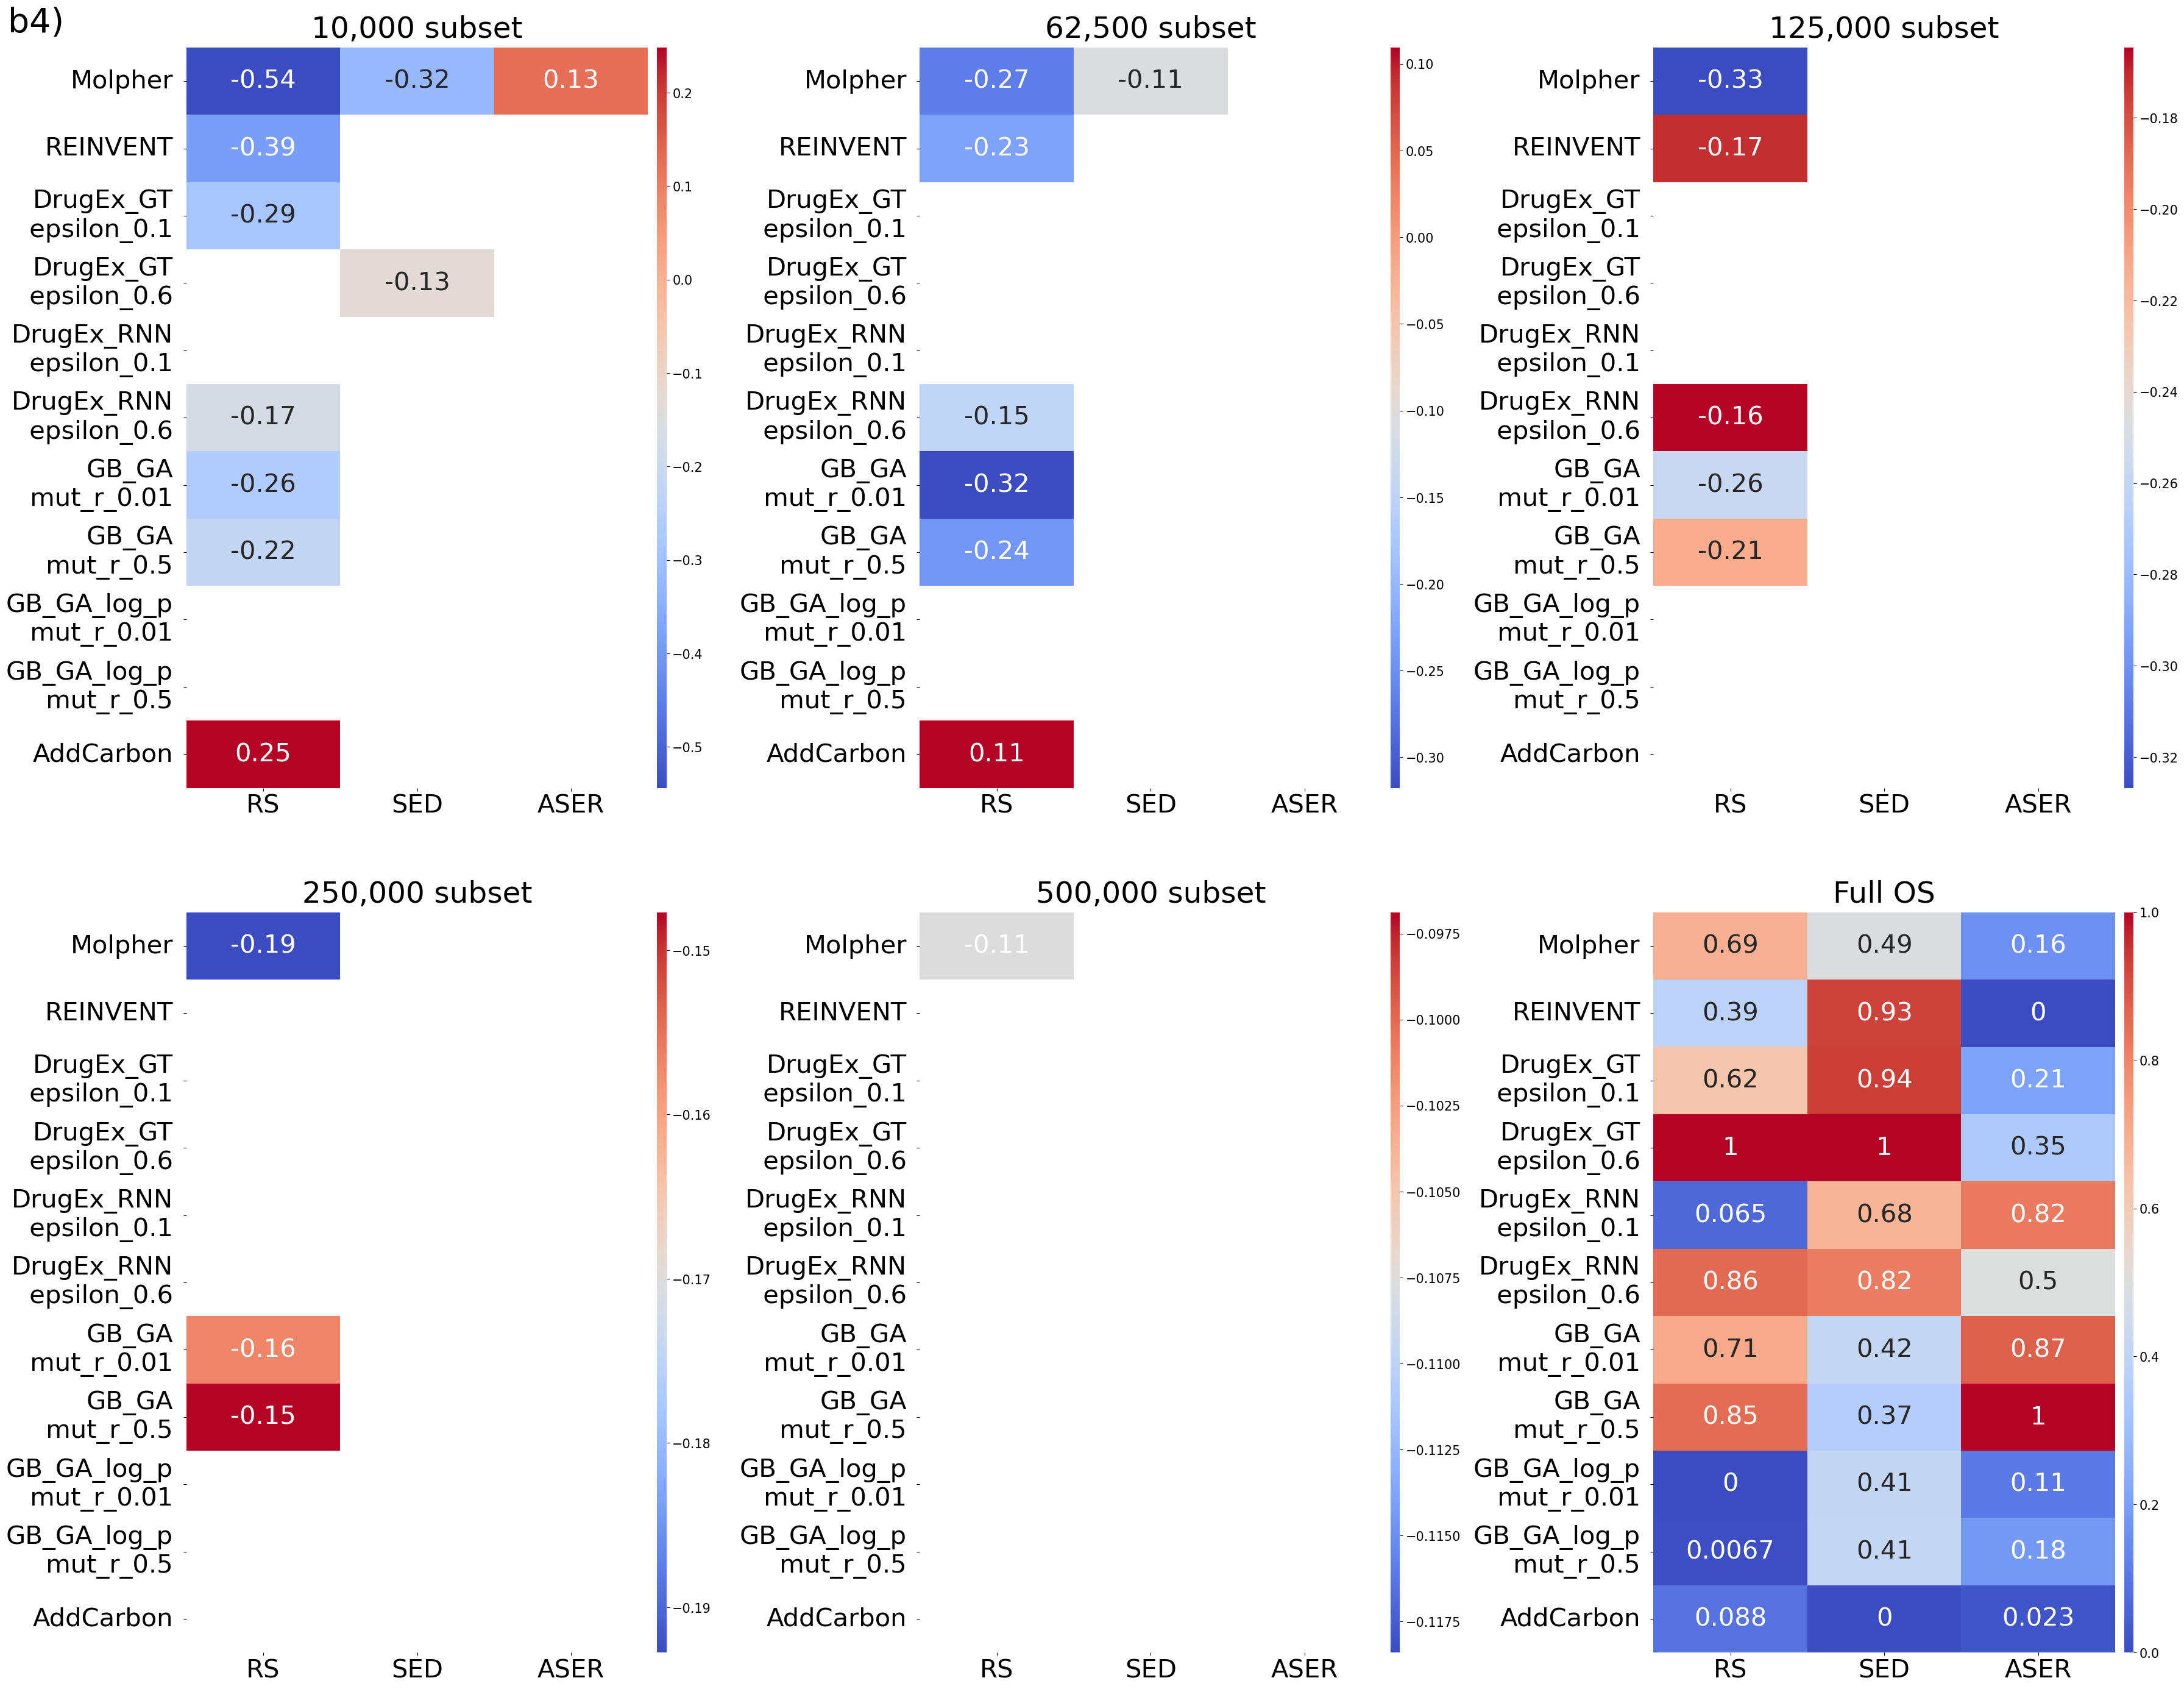

In [20]:
count = 1
for type_cluster in ['dis', 'sim']:
    for type_scaffold in ['csk', 'murcko']:
        data_dict = {}
        receptor = 'Leukocyte_elastase'
        # Load the baseline data (replace with your actual file paths)
        for subset in ['_10k','_62.5k', '_125k', '_250k', '_500k', '']:
        #for subset in ['_10k', '']:
            generators_name_list = [
                f"Molpher{subset}",
                f"REINVENT{subset}",
                f"DrugEx_GT_epsilon_0.1{subset}",
                f"DrugEx_GT_epsilon_0.6{subset}",
                f"DrugEx_RNN_epsilon_0.1{subset}",
                f"DrugEx_RNN_epsilon_0.6{subset}",
                f"GB_GA_mut_r_0.01{subset}",
                f"GB_GA_mut_r_0.5{subset}",
                f"GB_GA_log_p_mut_r_0.01{subset}",
                f"GB_GA_log_p_mut_r_0.5{subset}",
                f"addcarbon{subset}"
            ]
            
            using_norm_value = True #Define if use normalized values or not

            if using_norm_value:
                df = hv.preprocesing(type_cluster, type_scaffold, generators_name_list, receptor, data_folder)
            else:
                df = hv.preprocesing_org(type_cluster, type_scaffold, generators_name_list, receptor, data_folder)
            
            # Load the baseline data for the given split type and scaffold
            if subset == '': #baseline
                baseline_df = df
                
            
                
            data_dict[subset] = df
        numering = f"b{count})"
        #numering = ""
        
        name_save = f'figure_14b{count}'
        #name_save = f'figure_9'
        # Call the function to plot heatmaps
        hv.plot_heatmaps_with_diff_from_baseline(baseline_df, data_dict, type_cluster, type_scaffold, receptor = receptor, name_save = name_save, numering = numering, save_folder = f'../img/paper/figure_14/')
        count += 1

### Combined Heatmaps for All Generators and Receptors

- Define the generators, receptors, scaffold types, splits, and metrics that should be included in the figure.
- The `using_norm_values` parameter controls whether raw metric values or Min-Max normalized values are displayed.
- For manuscript-style interpretation, non-normalized values are usually recommended because they preserve the original metric scale.
- `plot_combined_heatmap_with_single_column_for_each_metric_rotated` is the main function for scaffold-based results. It creates one compact heatmap column per metric and compares generators across receptors, scaffold definitions, and splits.
- `plot_combined_heatmap_with_single_column_for_each_metric_pharm` is the analogous function for pharmacophore-based results.
- `plot_combined_heatmap_with_single_column_for_each_metric_rotated_binned` should be used when scaffold-based values need to be shown relative to the best result using effect-size thresholds.
- `plot_combined_heatmap_with_single_column_for_each_metric_rotated_binned_pharm` provides the same binned visualization for pharmacophore-based metrics.
- These functions read scaffold-based results from `data/results_scaffold_based/...` and pharmacophore-based results from `data/results_pharm_based/...`.

/home/filv/phd_projects/iga_2023/git_reccal/new/recall_metrics/src/heatmap_visualization.py:1116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


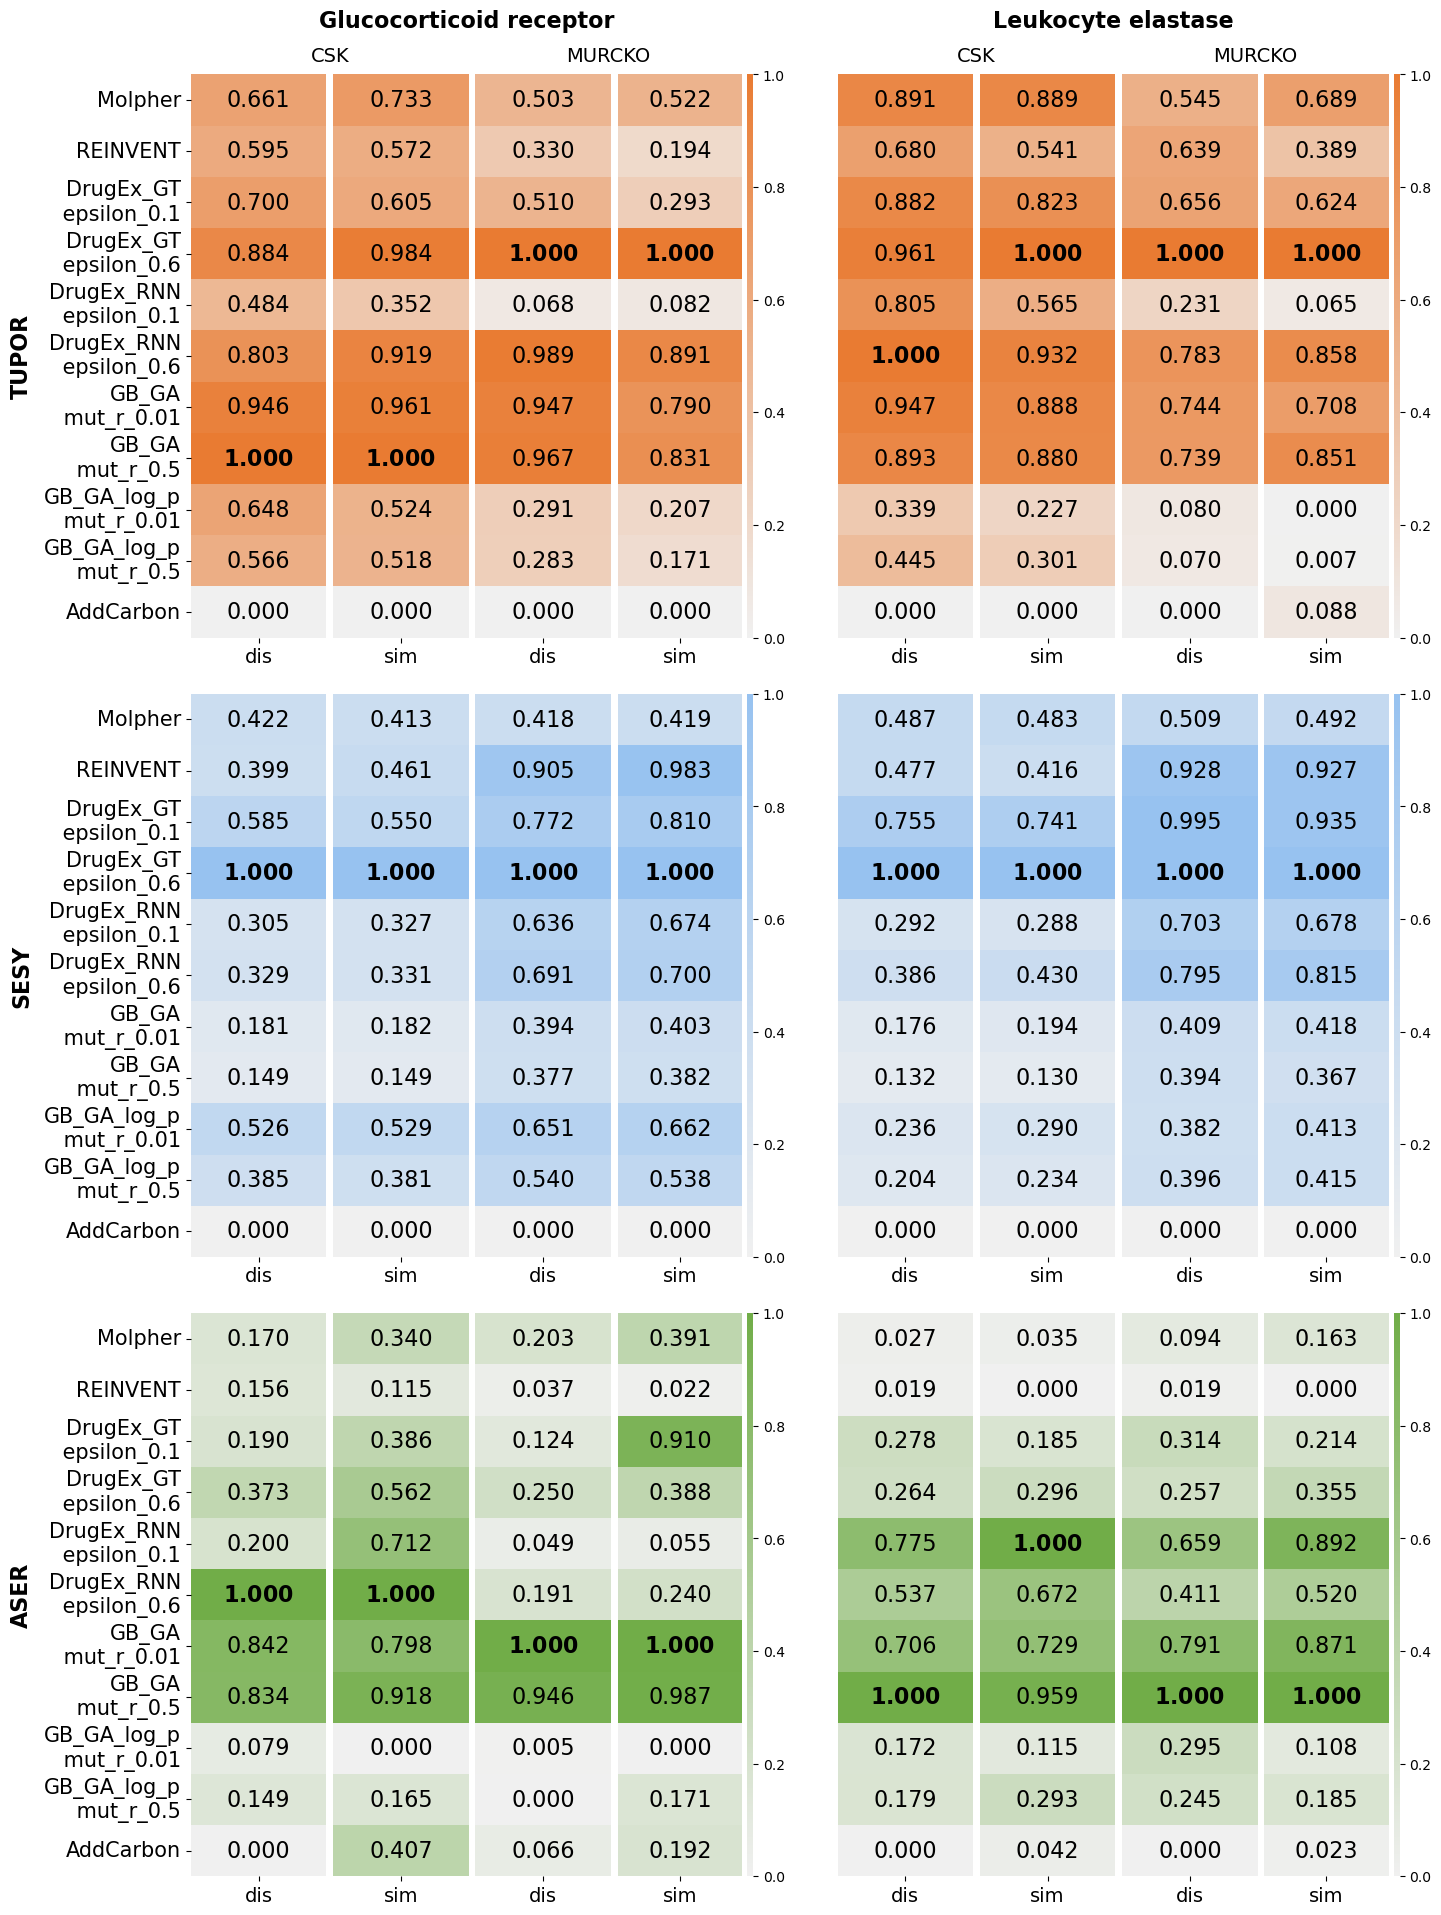

In [474]:
generators = ['Molpher', 'REINVENT', 'DrugEx_GT_epsilon_0.1', 'DrugEx_GT_epsilon_0.6', 'DrugEx_RNN_epsilon_0.1',\
              'DrugEx_RNN_epsilon_0.6', 'GB_GA_mut_r_0.01', 'GB_GA_mut_r_0.5', 'GB_GA_log_p_mut_r_0.01', 'GB_GA_log_p_mut_r_0.5', 'addcarbon' ]
receptors = ['Glucocorticoid_receptor', 'Leukocyte_elastase']
scaffolds = ['csk', 'murcko']
splits = ['dis', 'sim']
metrics = ['TUPOR', 'SESY', 'ASER']

hv.plot_combined_heatmap_with_single_column_for_each_metric_rotated(generators, receptors, scaffolds, splits, save_name="all_res_norm",using_norm_values=True, data_folder=data_folder, save_folder = '../img/paper/figure_12') 

/home/filv/phd_projects/iga_2023/git_reccal/new/diseration_git/generative_models_for_de_novo_molecular_design/src/heatmap_visualization.py:1369: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle(title, fontsize=14, y=0.995)


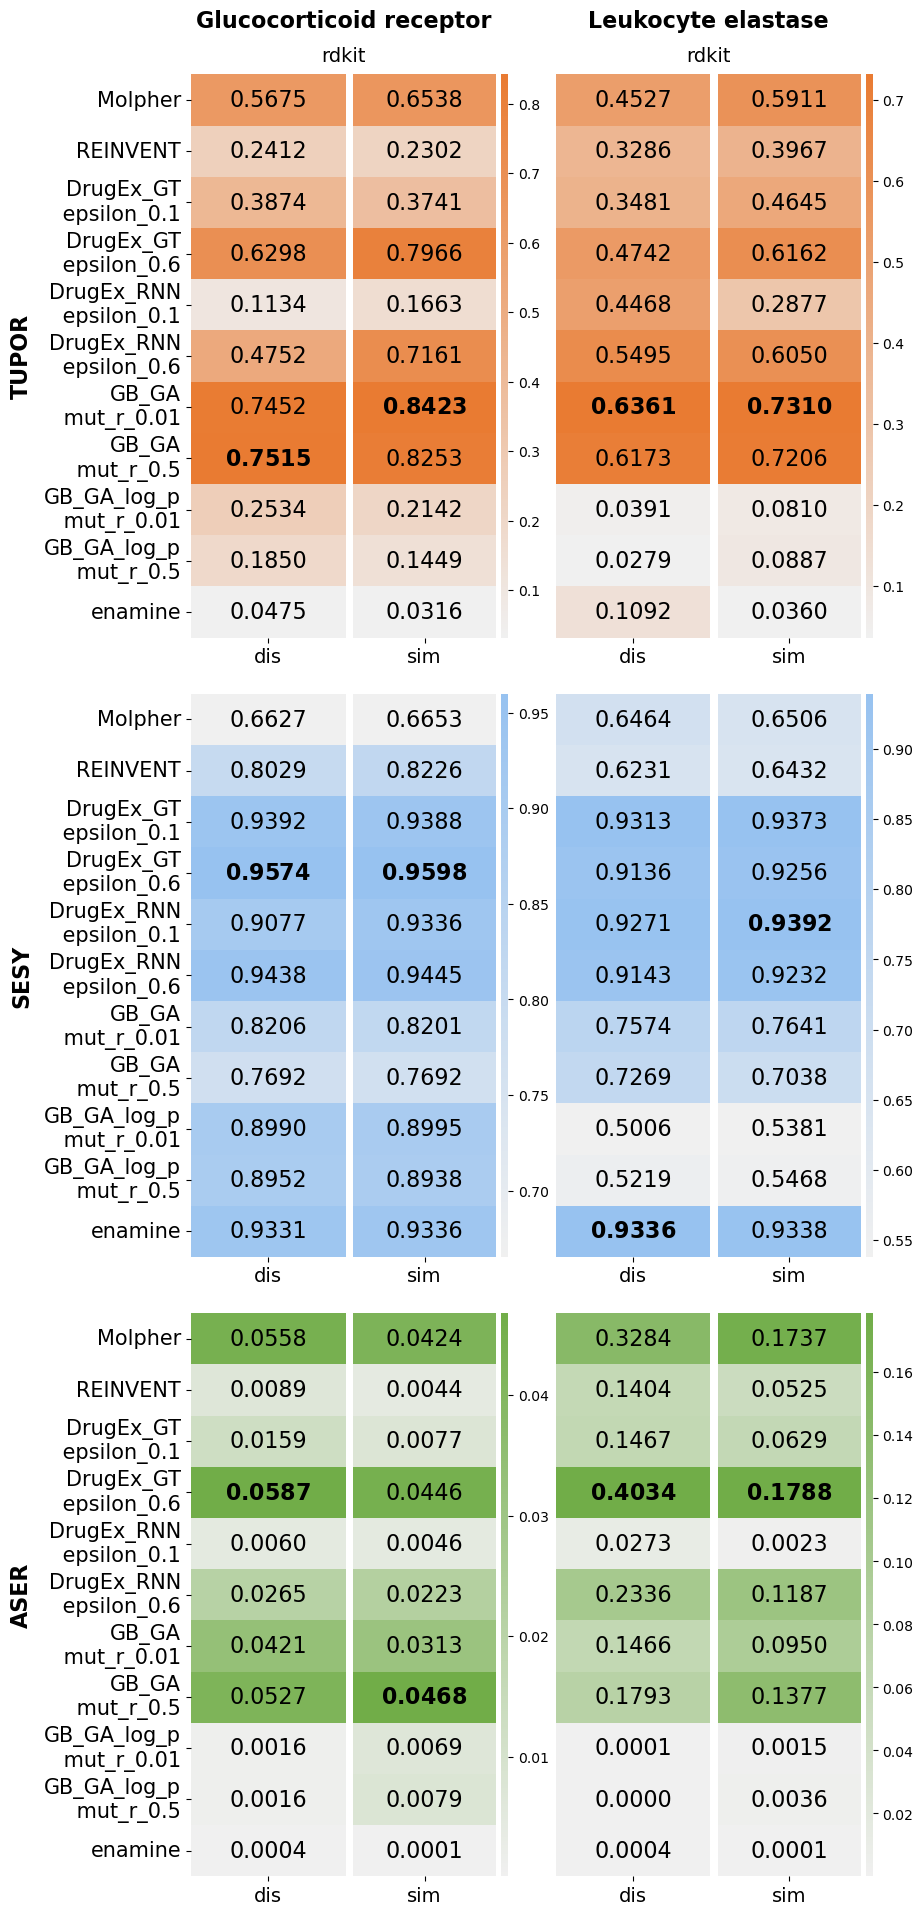

In [94]:
generators = ['Molpher_250k','REINVENT_250k', 'DrugEx_GT_epsilon_0.1_250k', 'DrugEx_GT_epsilon_0.6_250k','DrugEx_RNN_epsilon_0.1_250k',
              'DrugEx_RNN_epsilon_0.6_250k',\
                         'GB_GA_mut_r_0.01_250k',\
                       'GB_GA_mut_r_0.5_250k',
            'GB_GA_log_p_mut_r_0.01_250k', 
    'GB_GA_log_p_mut_r_0.5_250k', \
              'enamine_250k'
             ]

receptors = ['Glucocorticoid_receptor', 'Leukocyte_elastase']
type_fps = ['rdkit']
splits = ['dis', 'sim']
metrics = ['TUPOR', 'SESY', 'ASER']

hv.plot_combined_heatmap_with_single_column_for_each_metric_pharm(
    generators, 
    receptors, 
    type_fps, 
    splits, 
    save_name="all_res_pharm",
    using_norm_values=False, 
    data_folder=data_folder,
    user_threshold = 0.7,
    threshold_sim = 0.8,
    threshold_dis = 0.7,
    save_folder ='../../data/img') 

/home/filv/phd_projects/iga_2023/git_reccal/new/diseration_git/generative_models_for_de_novo_molecular_design/src/heatmap_visualization.py:1336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


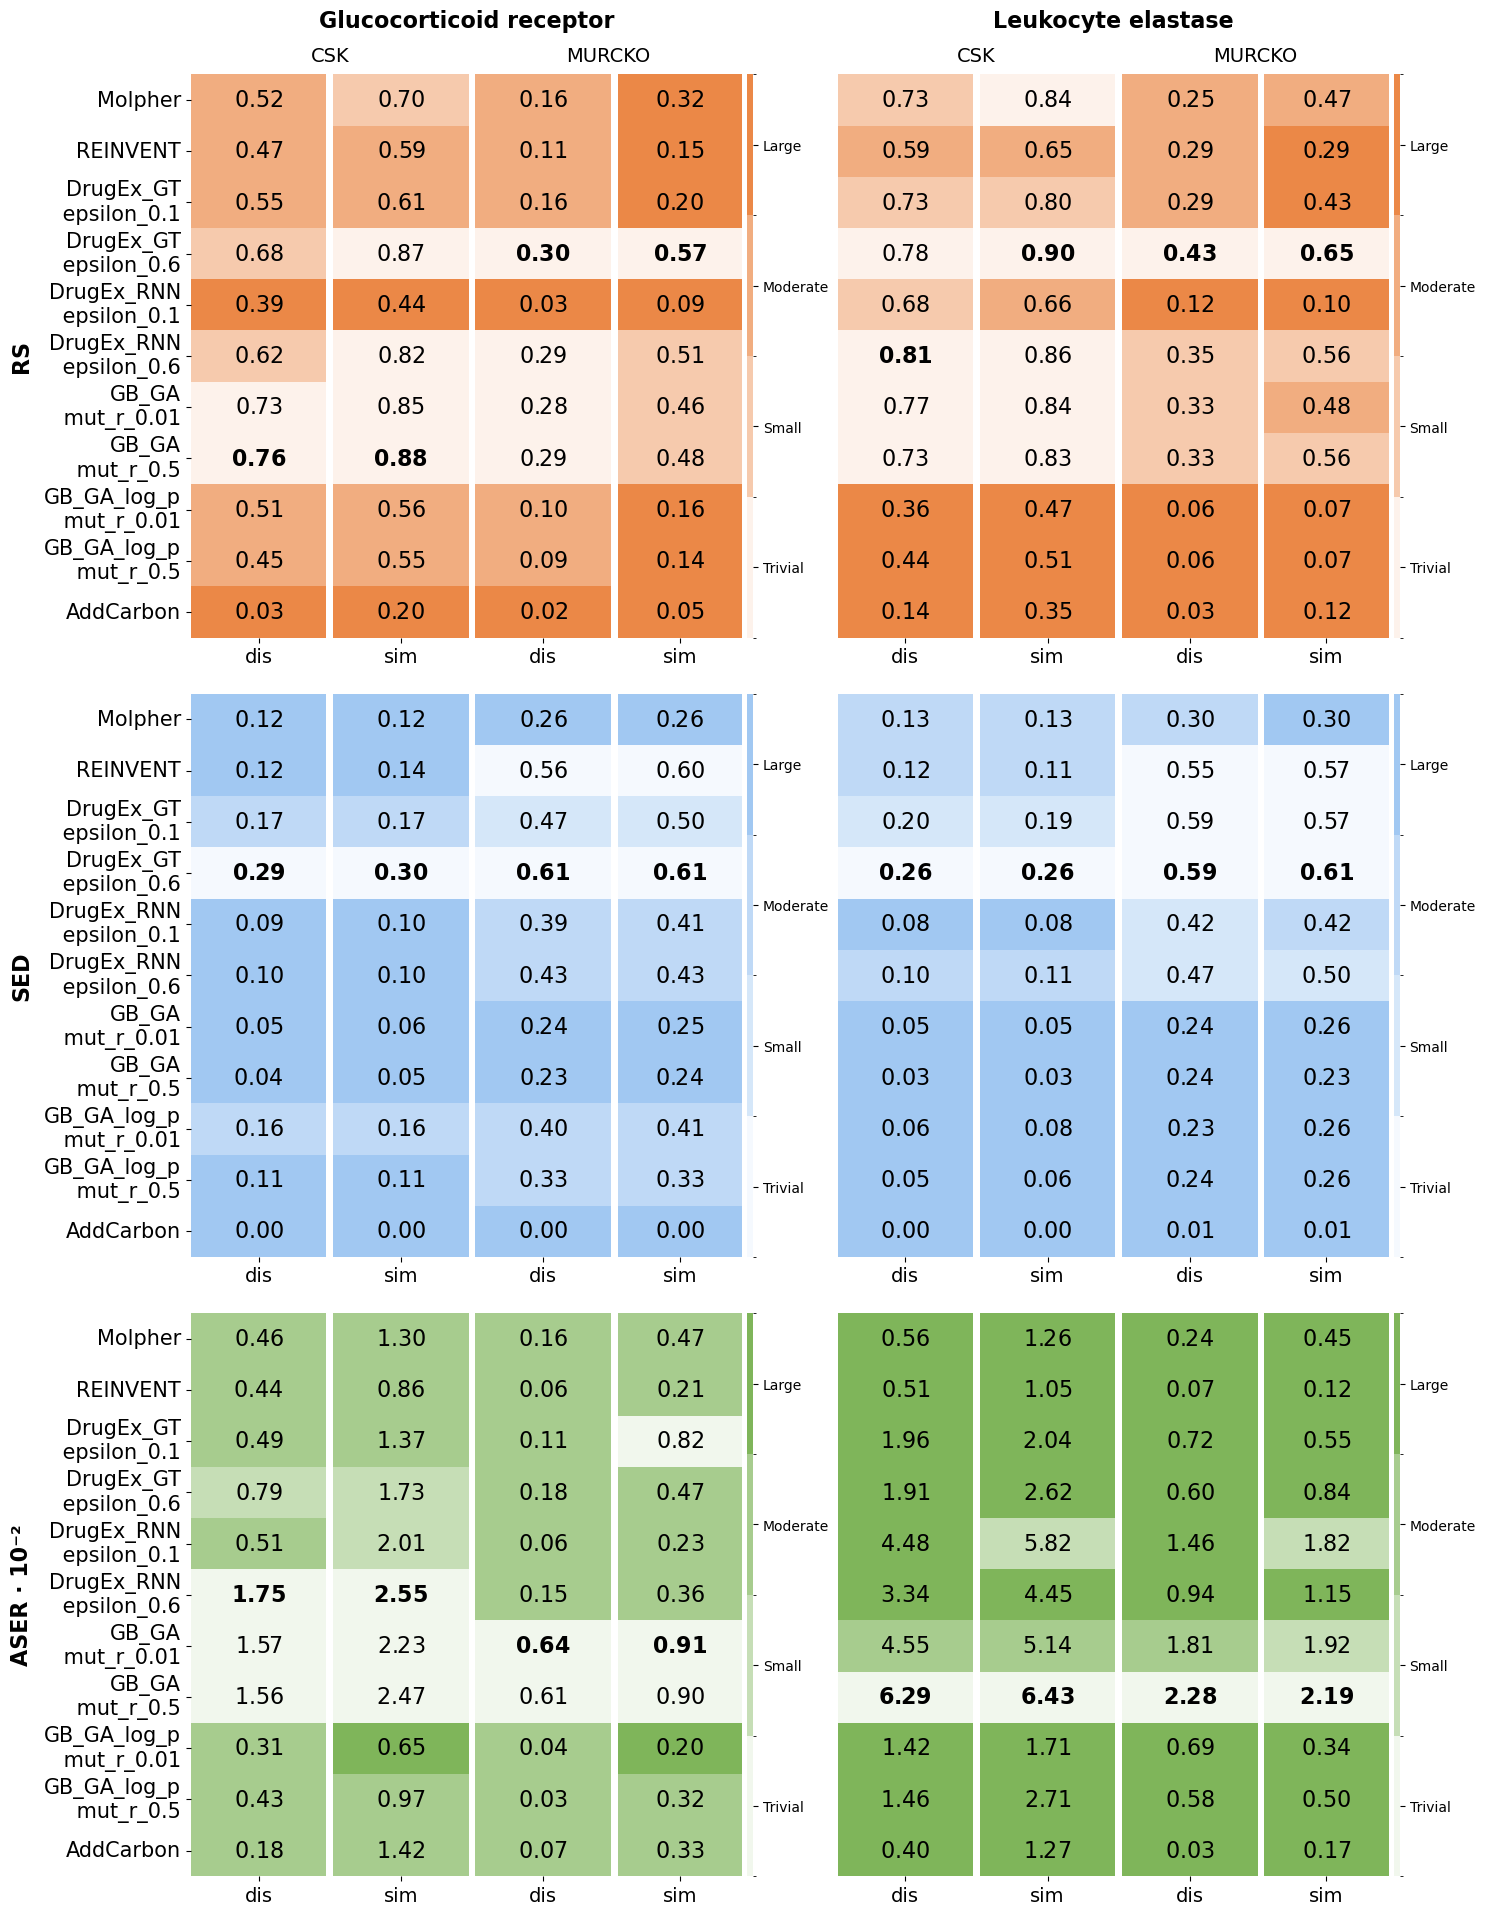

In [32]:
generators = ['Molpher', 'REINVENT', 'DrugEx_GT_epsilon_0.1', 'DrugEx_GT_epsilon_0.6', 'DrugEx_RNN_epsilon_0.1',\
              'DrugEx_RNN_epsilon_0.6', 'GB_GA_mut_r_0.01', 'GB_GA_mut_r_0.5', 'GB_GA_log_p_mut_r_0.01', 'GB_GA_log_p_mut_r_0.5', 'addcarbon' ]
receptors = ['Glucocorticoid_receptor', 'Leukocyte_elastase']
scaffolds = ['csk', 'murcko']
splits = ['dis', 'sim']
metrics = ['RS', 'SED', 'ASER']




hv.plot_combined_heatmap_with_single_column_for_each_metric_rotated_binned(
    generators=generators,
    receptors=receptors,
    scaffolds=scaffolds,
    splits=splits,
    using_norm_values=False,
    data_folder="../../",
    effect_thresholds_csv="effect_size_thresholds_scaffolds.csv",
    save_folder="img/heat_map",
    save_name="all_res_scaffold_based_with_thresholds",
    title=""
)


/home/filv/phd_projects/iga_2023/git_reccal/new/diseration_git/generative_models_for_de_novo_molecular_design/src/heatmap_visualization.py:1605: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.99])


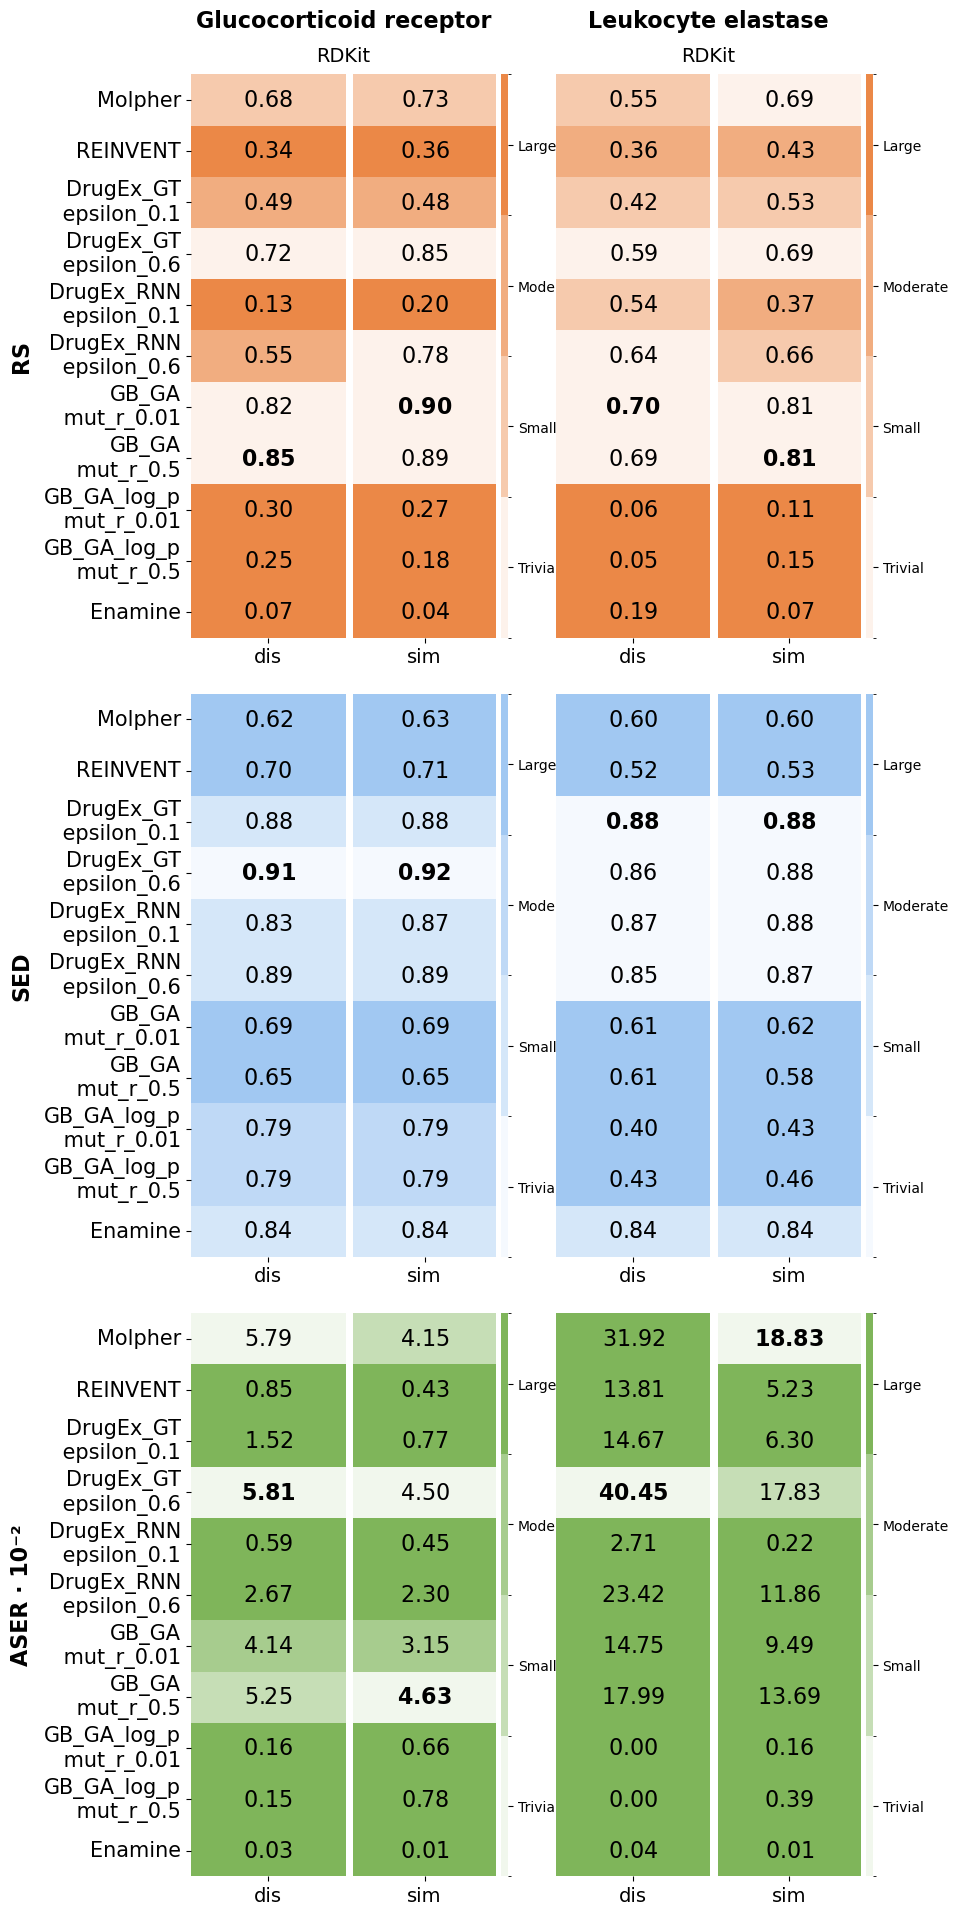

In [37]:
generators = ['Molpher', 'REINVENT', 'DrugEx_GT_epsilon_0.1', 'DrugEx_GT_epsilon_0.6', 'DrugEx_RNN_epsilon_0.1',\
              'DrugEx_RNN_epsilon_0.6', 'GB_GA_mut_r_0.01', 'GB_GA_mut_r_0.5', 'GB_GA_log_p_mut_r_0.01', 'GB_GA_log_p_mut_r_0.5', 'enamine']
receptors = ['Glucocorticoid_receptor', 'Leukocyte_elastase']
phfps = ['rdkit']
splits = ['dis', 'sim']
metrics = ['RS', 'SED', 'ASER']




hv.plot_combined_heatmap_with_single_column_for_each_metric_rotated_binned_pharm(
    generators=generators,
    receptors=receptors,
    phfps=phfps,
    splits=splits,
    using_norm_values=False,
    data_folder="../../",
    effect_thresholds_csv="effect_size_thresholds_ph4_rdkit.csv",
    user_threshold = 0.7,
    threshold_sim = 0.8,
    threshold_dis = 0.7,
    save_folder="img/heat_map",
    save_name="all_res_pharm_based_with_thresholds",
    title=""
)
